# 03: Conformance assessment

Ports `build_conformance_voltvar.py` and `build_conformance_voltwatt.py` to DuckDB over the local store. 

Every AS/NZS 4777.2 expression is imported from `bms_sa_review.shared.as4777_curves` and runs unchanged

Three questions are kept separate:
1. **Maximum-output / required-Q conformance**: Did the inverter do what the curve asks?
2. **Whether the observation was informative** about an active response.
3. **Counterfactual-supported curtailed energy**: *not available yet*, needs D12.

The 10% site threshold is a project reporting convention, not a tolerance granted by AS/NZS 4777.2.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

_current = Path.cwd().resolve()
REPO_ROOT = next(
    (p for p in (_current, *_current.parents)
     if (p / "solar_edge").is_dir() and (p / "bms_sa_review").is_dir()),
    None,
)
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import pandas as pd

from solar_edge.config import se_config as C
from solar_edge.lib import se_store, se_contract as contract, se_params
from solar_edge.lib import se_conformance as cf
from solar_edge.lib import se_adverse as adv
from solar_edge.lib import se_plots as plots
from solar_edge.lib import se_spatial as spat

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 220)

con = se_store.connect()
config = se_params.CONFIG
params = se_params.PARAMS
display(contract.manifest(config, params).query("section != 'convention'"))

,section,setting,value
18,cohort,months,2025-01 .. 2025-12 (12 months)
19,cohort,interval_h,0.083333
20,cohort,phase_cohort,all
21,cohort,day_night,all
22,cohort,derating_selection,include
23,cohort,night_anomaly_selection,exclude
24,cohort,min_days_observed,0
25,cohort,max_capacity_kva,30.0
26,cohort,min_site_intervals,1
27,basis,rating_basis,s_99


## 1. Volt-VAr conformance

Interval scoring follows the CTE chain of `build_conformance_voltvar.build_sql`:
required Q → ±4% tolerance band → AS4777 Figure 2.1 capability clamp → `Q_impact` → five categories.

Two assumptions:

- **Capacity basis is `s_99`**, not nameplate. It scales the required-Q curve, the tolerance band, the 20% assessability rule and the capability floor. Because `s_99` is an *observed* p99, a site that never approached its inverter limit gets a low `s_99`, and a smaller required Q
- **`capability_profile="review_corrected"`**: Reactive-power priority above 0.8·S, and intervals below 0.2·S marked unassessable rather than scored, since Figure 2.1 sets no quantified minimum there.

BMS update: `reduced_nonconf` = adverse + inactive + significant shortfall. `Q_near_conformant` is excluded: those inverters deliver 90–110% of required reactive power.

In [2]:
vvar_site_day = cf.voltvar_site_day(con, config, params)
print(f"{len(vvar_site_day):,} site-days scored")

vvar_summary = cf.voltvar_summary(vvar_site_day, by_cohort=True)
display(vvar_summary.T)

560,087 site-days scored


,0,1
cohort,single-phase,three-phase
n_sites,1165,415
all_intervals,61526522,23763800
exposed_intervals,44501999,16732635
pct_exposed_of_all,72.33,70.412
capability_assessable_intervals,37563447,13133840
assessable_and_exposed_intervals,30871696,10372518
pct_assessable_of_exposed,69.371,61.99
Q_adverse_intervals,22932811,128502
Q_adverse_pct,61.051,0.978


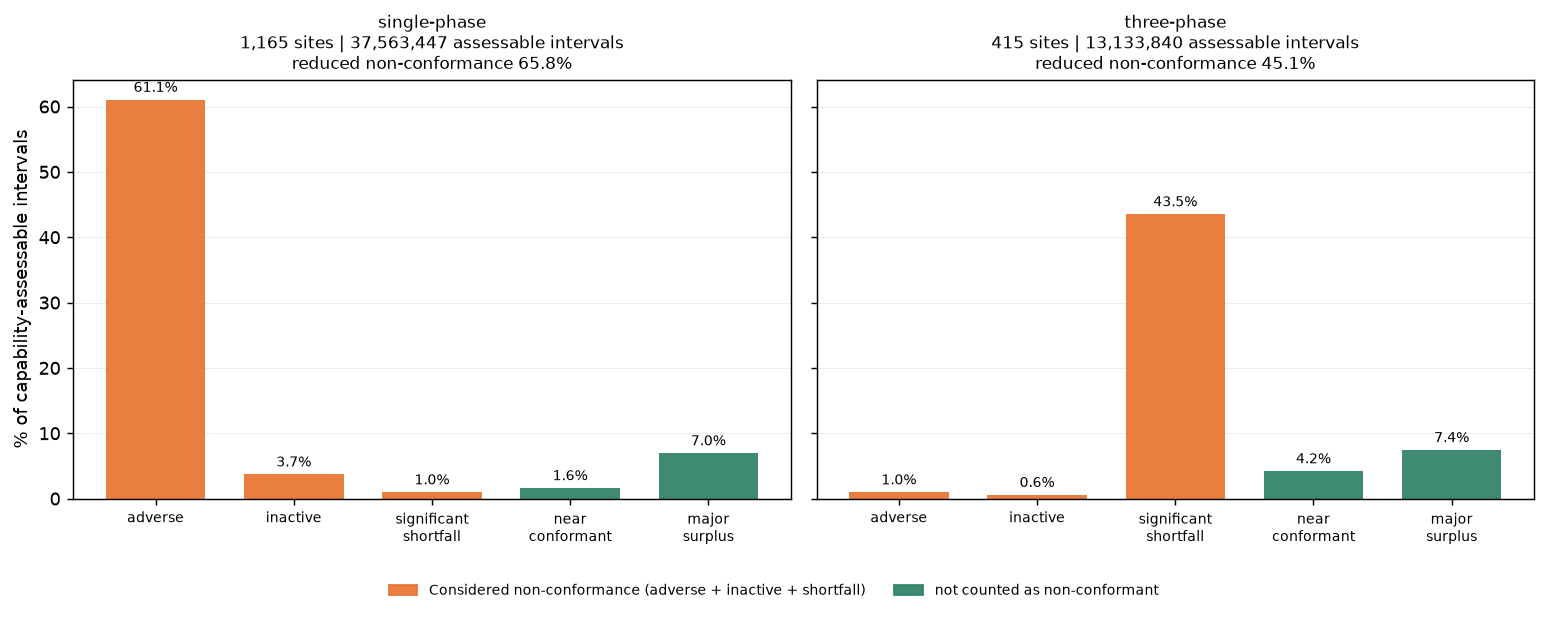

In [3]:
display(plots.plot_q_categories(vvar_summary))

### Same result unpacked:

| Measure | Denominator | Answers |
|---|---|---|
| **% of assessable intervals** | every interval counts once | how *often* it happens |
| **% of sites** | every site counts once, 10% rule per category | how *many inverters* |
| **kVArh** | none. Absolute total | how much reactive support was *actually missing* |
| **kVArh / kW / h** | site rating × assessable hours | how *badly*, per inverter, per hour |

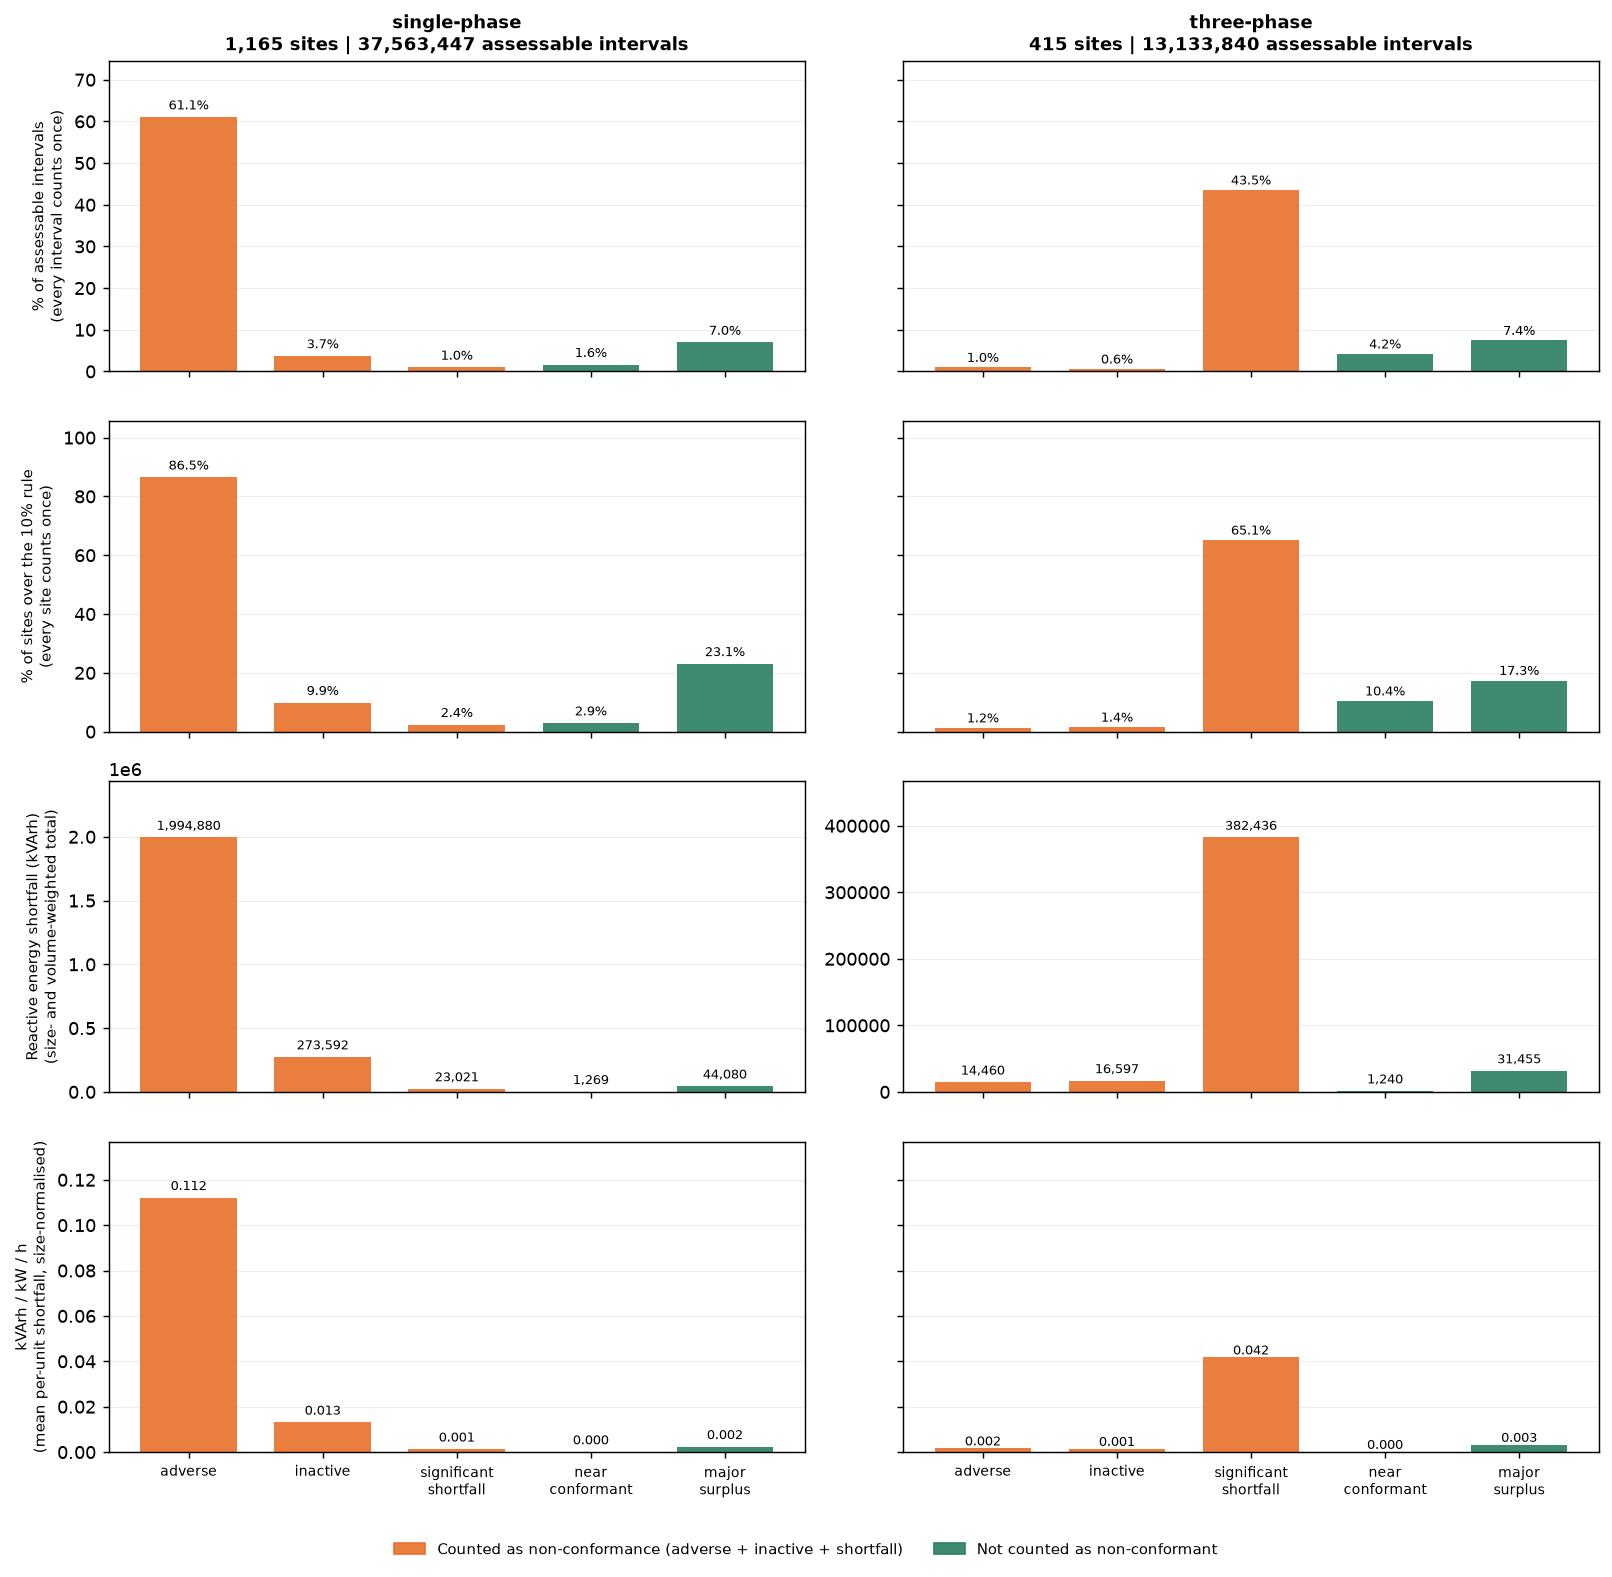

,cohort,category,n_sites,assessable_intervals,pct_intervals,pct_sites,kvarh,kvarh_per_kw_per_h
0,single-phase,Q_adverse,1165,37563447,61.051,86.524,1994880.38,0.11212
1,single-phase,Q_inactive,1165,37563447,3.715,9.871,273591.54,0.01312
2,single-phase,Q_significant_shortfall,1165,37563447,0.984,2.403,23021.00,0.00127
3,single-phase,Q_near_conformant,1165,37563447,1.619,2.918,1269.03,0.00006
4,single-phase,Q_major_surplus,1165,37563447,6.958,23.090,44080.36,0.00237
5,three-phase,Q_adverse,415,13133840,0.978,1.205,14460.03,0.00167
6,three-phase,Q_inactive,415,13133840,0.580,1.446,16596.94,0.00146
7,three-phase,Q_significant_shortfall,415,13133840,43.540,65.060,382435.58,0.04177
8,three-phase,Q_near_conformant,415,13133840,4.211,10.361,1239.76,0.00014
9,three-phase,Q_major_surplus,415,13133840,7.444,17.349,31455.33,0.00324


In [4]:
vvar_measures = cf.voltvar_measures(vvar_site_day, config)
display(plots.plot_conformance_dashboard(vvar_measures))
display(vvar_measures)

## 2. Volt-VAr site verdicts

**The 10% rule, exactly as CICCADA milestone 3 applies it** (`conformance_metrics.aggregate_sites`):

```
nonconf_frac = reduced_nonconf_count / capability_assessable_count
conformant   = nonconf_frac <  0.10      # STRICTLY less than
nonconformant= nonconf_frac >= 0.10
```

Obs:

- The denominator is **capability-assessable intervals**, not all intervals and not
  voltage-exposed intervals. Below 0.2·S the standard sets no quantified requirement.
- The comparison is **strict**. A site sitting exactly on 0.10 is non-conformant.

In [5]:
vvar_verdicts = cf.voltvar_site_verdicts(vvar_site_day, config)
display(pd.crosstab(
    vvar_verdicts.is_three_phase.map({False: "single-phase", True: "three-phase"}),
    vvar_verdicts.verdict, normalize="index").round(4) * 100)
display(pd.crosstab(
    vvar_verdicts.is_three_phase.map({False: "single-phase", True: "three-phase"}),
    vvar_verdicts.verdict, margins=True))

verdict,conformant,non-conformant
is_three_phase,,
single-phase,13.13,86.87
three-phase,33.98,66.02


verdict,conformant,non-conformant,All
is_three_phase,,,
single-phase,153,1012,1165
three-phase,141,274,415
All,294,1286,1580


### Aggregate verdict

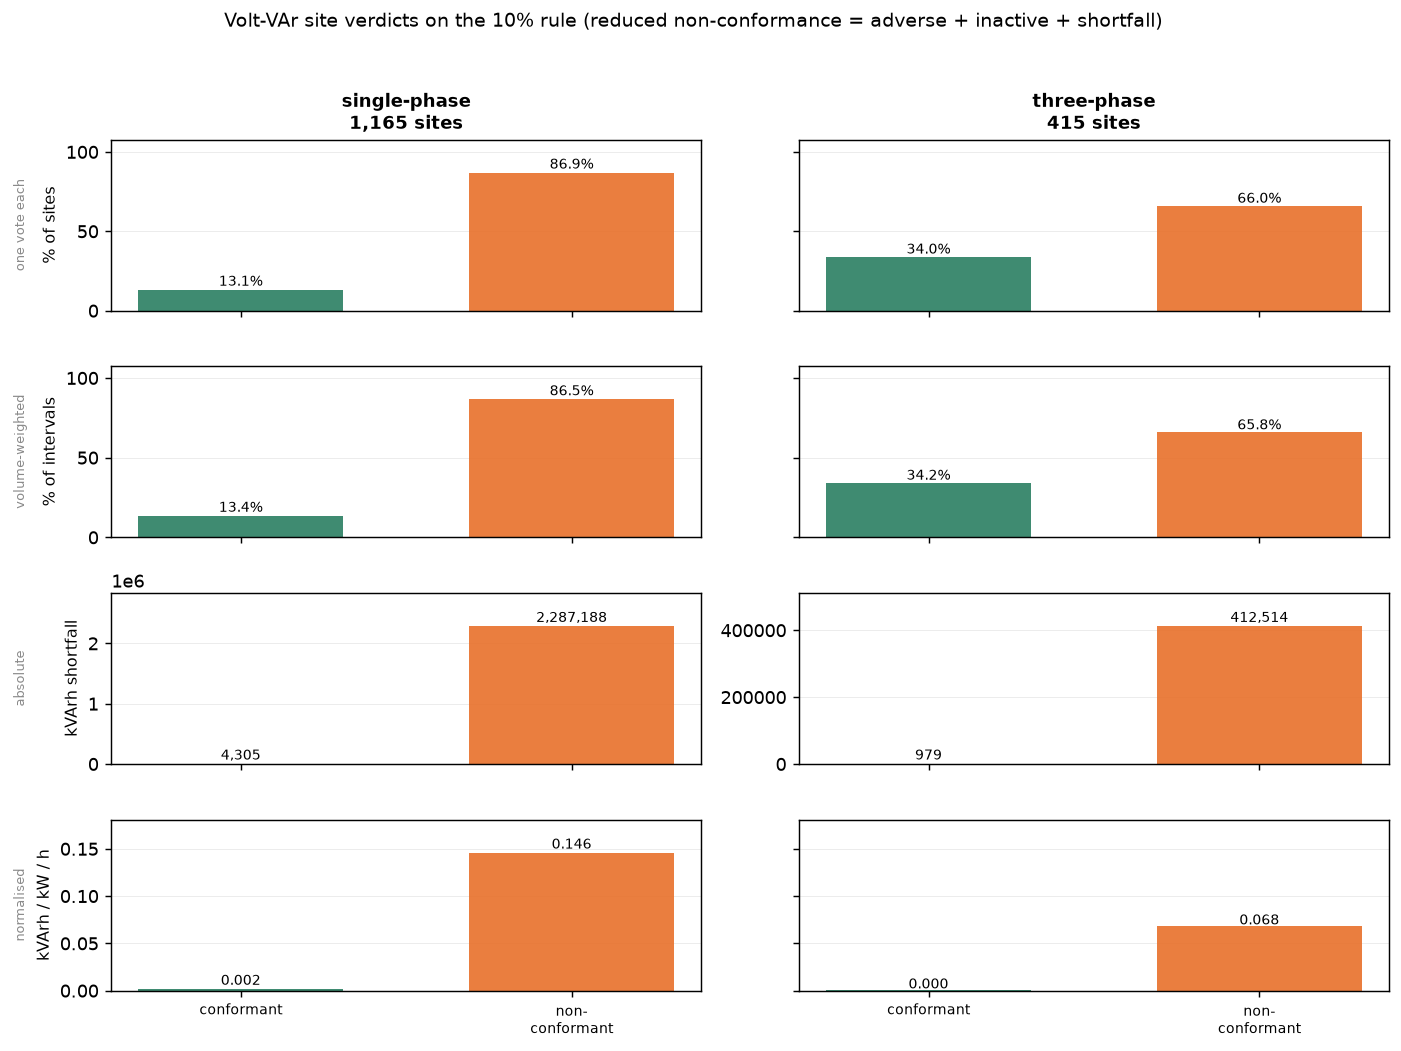

,cohort,denominator,verdict,n_sites,pct_sites,pct_intervals,kvarh,kvarh_per_kw_per_h
0,single-phase,all,conformant,153,13.133,13.450,4304.57,0.00184
1,single-phase,all,non-conformant,1012,86.867,86.550,2287188.35,0.14587
2,three-phase,all,conformant,141,33.976,34.186,978.63,0.00034
3,three-phase,all,non-conformant,274,66.024,65.814,412513.92,0.06804


In [6]:
vvar_verdict_measures = cf.site_verdict_measures(vvar_site_day, config)
display(plots.plot_site_verdicts(vvar_verdict_measures, config))
display(vvar_verdict_measures)

#### Denominator conventions: Volt-VAr

**Which sites belong in the denominator?** Two defensible answers, and they are *not* the difference between "conformant" and "not tested".

| convention | denominator | question |
|---|---|---|
| `assessed` | sites with ≥ 1 interval in the assessment population | *of the inverters actually tested, how many passed?* |
| `all` | every site in the cohort | *what share of the fleet has demonstrated conformance?* |

`assessed` is what the original study did. 

In `Volt-Watt-Trino.ipynb` the build carries `HAVING avg(voltage) > 253`, so a site that never saw high voltage produces **no rows at
all** and cannot reach any downstream rate; `bms_sa_review.conformance_metrics.aggregate_sites`
does the same explicitly with `d[d[denominator] >= min_intervals]`, and `fleet_result`
keeps `n_sites_contained_in_table` and `n_assessed_sites` as separate fields for exactly
this reason.

**Neither convention counts a never-tested site as conformant.** 

In [7]:
vvar_denominators = cf.denominator_comparison(vvar_site_day, "voltvar", config)
display(vvar_denominators.drop(columns="denominator_intervals"))
cf.denominator_note(vvar_denominators)

,mode,cohort,n_sites_in_table,n_assessed_sites,n_not_assessable,pct_excluded,pct_conformant_assessed,pct_nonconformant_assessed,pct_conformant_all,pct_nonconformant_all
0,Volt-VAr,single-phase,1165,1165,0,0.0,13.133,86.867,13.133,86.867
1,Volt-VAr,three-phase,415,415,0,0.0,33.976,66.024,33.976,66.024
2,Volt-VAr,all sites,1580,1580,0,0.0,18.608,81.392,18.608,81.392


Volt-VAr

  Every one of the 1,580 sites has at least 1 interval in the
  denominator, so 'assessed only' and 'whole cohort' are the same population
  and both give 18.6% conformant.

  Worth stating explicitly rather than leaving implied: the choice
  that moves the Volt-Watt headline by ~57 points is immaterial here,
  because Volt-VAr's band (V > 240 V, P >= 0.2 S) catches every site.


## 3. Volt-VAr breakdowns

Two views per dimension, deliberately kept apart because they have different
denominators and answer different questions:

- **`site_pct`**: % of *sites* conformant / non-conformant, on the 10% rule. Equal weight per site.
- **`interval_pct`**: % of capability-assessable *intervals* in each category. Weighted by how much each site was observed.


STATE — % of SITES by verdict (10% rule)


,site_state,n_sites,pct_sites_conformant,pct_sites_non_conformant
0,New South Wales,560,13.75,86.25
1,Queensland,452,34.07,65.93
2,South Australia,568,11.09,88.91


STATE — % of ASSESSABLE INTERVALS by category


,site_state,n_sites,assessable_intervals,pct_Q_adverse,pct_Q_inactive,pct_Q_significant_shortfall,pct_Q_near_conformant,pct_Q_major_surplus,pct_reduced_nonconf
2,South Australia,568,18591709.0,49.193,2.928,18.328,1.659,5.086,70.449
0,New South Wales,560,17161264.0,53.064,4.064,9.222,2.147,6.763,66.350
1,Queensland,452,14944314.0,32.179,1.538,7.347,3.242,9.939,41.064


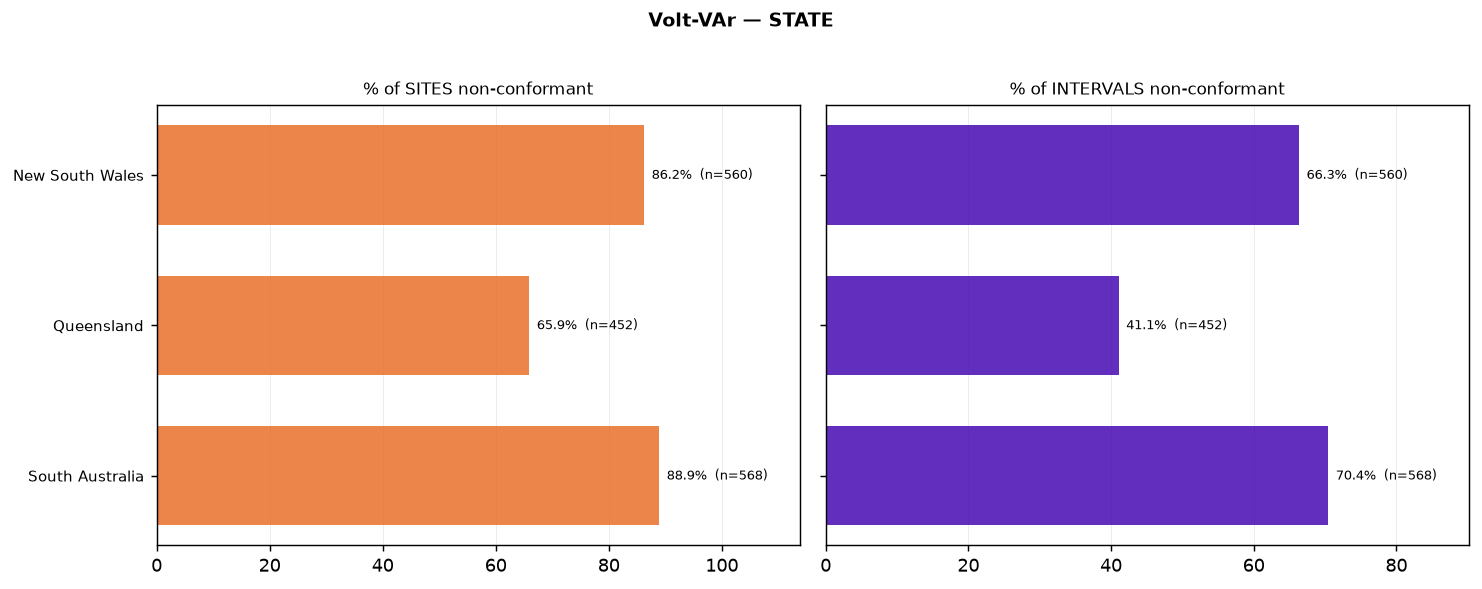


SYSTEM SIZE (s_99, kVA) — % of SITES by verdict (10% rule)


,capacity_band,n_sites,pct_sites_conformant,pct_sites_non_conformant
0,<3,2,0.00,100.00
1,3-4,15,13.33,86.67
2,4-5,353,9.35,90.65
3,5-6,486,16.67,83.33
4,6-8,348,19.83,80.17
5,8-10,262,29.77,70.23
6,>10,114,27.19,72.81


SYSTEM SIZE (s_99, kVA) — % of ASSESSABLE INTERVALS by category


,capacity_band,n_sites,assessable_intervals,pct_Q_adverse,pct_Q_inactive,pct_Q_significant_shortfall,pct_Q_near_conformant,pct_Q_major_surplus,pct_reduced_nonconf
0,<3,2,62276.0,34.223,0.000,0.000,4.048,31.704,34.223
1,3-4,15,487141.0,56.216,2.157,0.004,4.376,19.171,58.377
2,4-5,353,11173554.0,62.455,1.966,3.732,2.390,9.599,68.153
3,5-6,486,15847009.0,55.765,2.522,4.579,1.623,7.341,62.866
4,6-8,348,10993659.0,41.423,3.419,14.619,2.817,5.667,59.461
5,8-10,262,8449945.0,24.408,4.210,22.474,2.587,5.164,51.092
6,>10,114,3683703.0,9.074,2.992,39.065,2.301,4.973,51.132


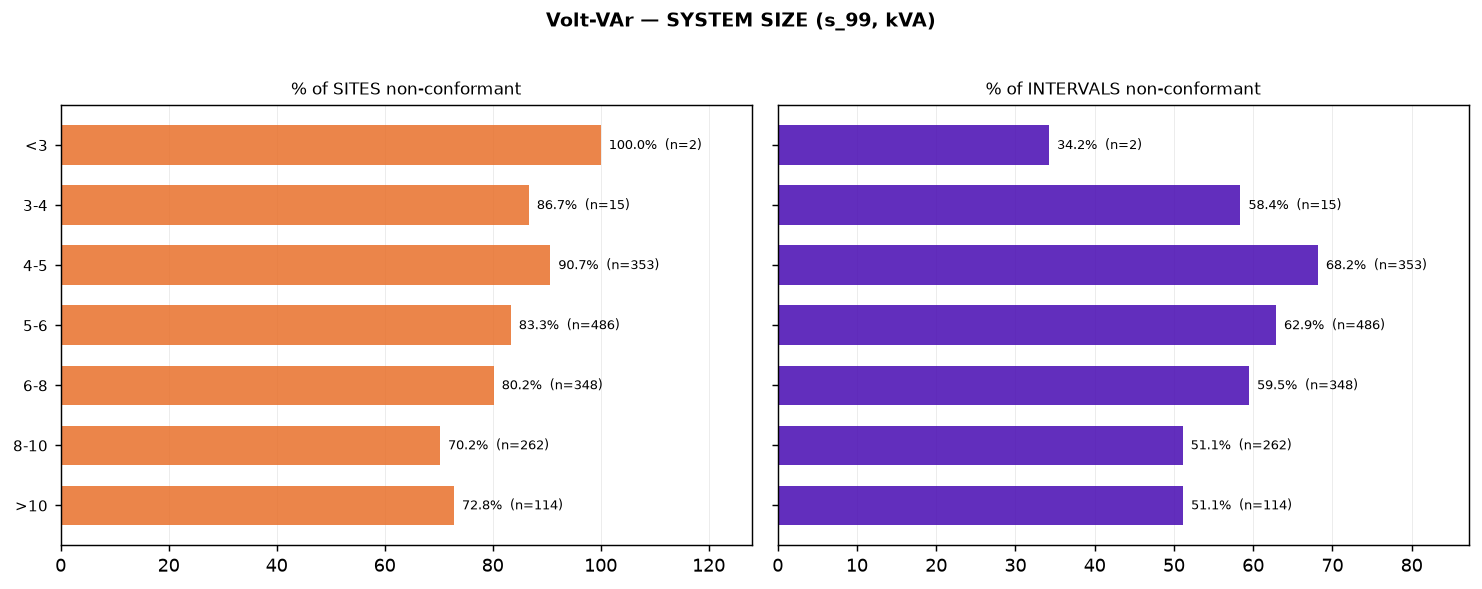


PHASE COHORT — % of SITES by verdict (10% rule)


,cohort,n_sites,pct_sites_conformant,pct_sites_non_conformant
0,single-phase,1165,13.13,86.87
1,three-phase,415,33.98,66.02


PHASE COHORT — % of ASSESSABLE INTERVALS by category


,cohort,n_sites,assessable_intervals,pct_Q_adverse,pct_Q_inactive,pct_Q_significant_shortfall,pct_Q_near_conformant,pct_Q_major_surplus,pct_reduced_nonconf
0,single-phase,1165,37563447.0,61.051,3.715,0.984,1.619,6.958,65.750
1,three-phase,415,13133840.0,0.978,0.580,43.540,4.211,7.444,45.098


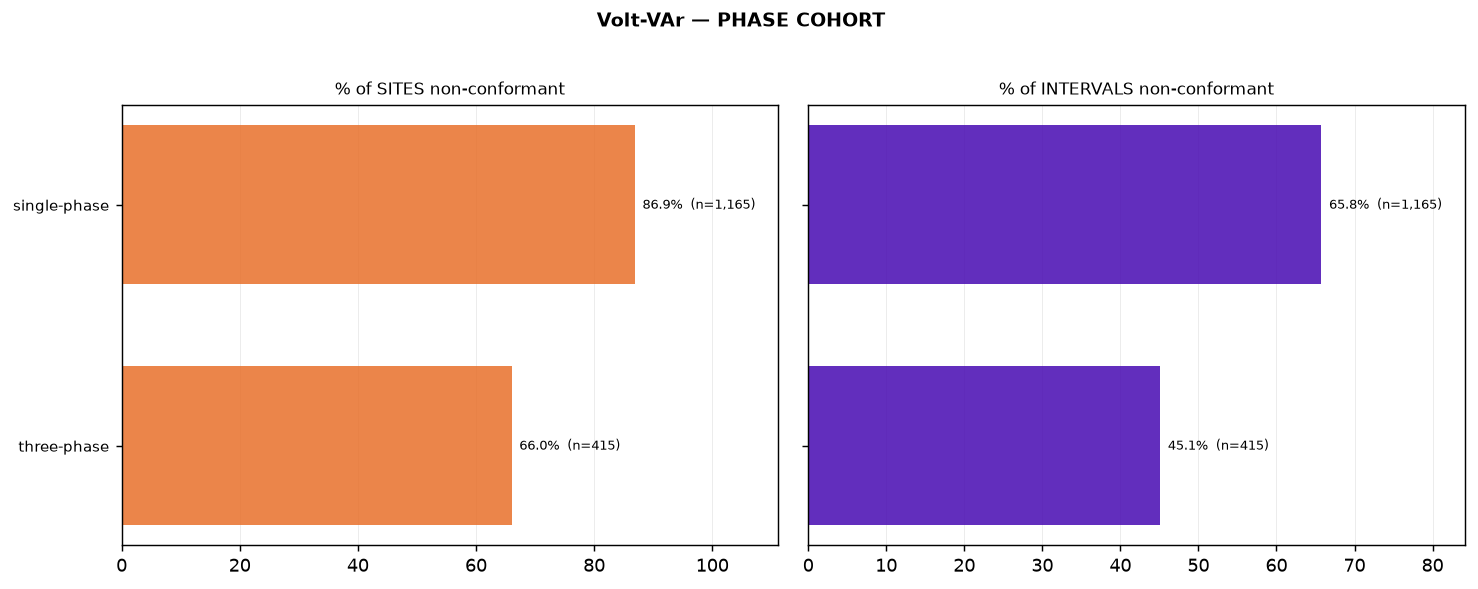

In [8]:
for dimension, label in [("site_state", "STATE"),
                         ("capacity_band", "SYSTEM SIZE (s_99, kVA)"),
                         ("cohort", "PHASE COHORT")]:
    site_pct, interval_pct = cf.voltvar_breakdown(con, vvar_site_day, by=dimension,
                                                  config=config)
    print(f"\n{'=' * 100}\n{label} — % of SITES by verdict (10% rule)\n{'=' * 100}")
    display(site_pct)
    print(f"{label} — % of ASSESSABLE INTERVALS by category")
    display(interval_pct)
    display(plots.plot_breakdown_rates(
        site_pct, interval_pct, dimension, "pct_reduced_nonconf",
        label=f"Volt-VAr — {label}"))

### By postcode

In [9]:
pc_sites, pc_intervals = cf.voltvar_breakdown(con, vvar_site_day, by="postcode",
                                              config=config)
big = pc_intervals[pc_intervals.n_sites >= 5].copy()
print(f"{len(pc_intervals):,} postcodes; {len(big):,} with at least 5 sites\n")
print("Highest reduced non-conformance:")
display(big.nlargest(10, "pct_reduced_nonconf"))
print("Lowest:")
display(big.nsmallest(10, "pct_reduced_nonconf"))

pc_intervals.to_csv(C.ARTEFACT_DIR / "voltvar_by_postcode.csv", index=False)
pc_sites.to_csv(C.ARTEFACT_DIR / "voltvar_sites_by_postcode.csv", index=False)

504 postcodes; 98 with at least 5 sites

Highest reduced non-conformance:


,postcode,n_sites,assessable_intervals,pct_Q_adverse,pct_Q_inactive,pct_Q_significant_shortfall,pct_Q_near_conformant,pct_Q_major_surplus,pct_reduced_nonconf
172,2640,7,238484.0,75.161,10.024,13.436,0.030,0.324,98.620
102,2287,10,312666.0,62.578,34.955,0.000,0.143,1.097,97.532
98,2283,5,141508.0,81.110,15.721,0.000,0.099,1.136,96.831
426,5112,5,172470.0,55.400,6.599,32.333,0.395,1.675,94.331
448,5162,7,211385.0,77.869,2.754,12.060,0.439,1.563,92.683
429,5115,6,197081.0,90.248,0.065,0.000,0.461,5.465,90.313
122,2322,8,234750.0,77.719,0.134,11.300,0.682,3.376,89.153
121,2321,9,291721.0,60.250,18.133,8.756,0.278,2.221,87.139
367,5021,6,202164.0,40.583,14.505,32.032,0.827,0.273,87.120
393,5062,14,445080.0,37.419,3.474,46.040,0.668,1.669,86.932


Lowest:


,postcode,n_sites,assessable_intervals,pct_Q_adverse,pct_Q_inactive,pct_Q_significant_shortfall,pct_Q_near_conformant,pct_Q_major_surplus,pct_reduced_nonconf
320,4575,8,247692.0,8.417,0.000,4.505,5.243,8.473,12.921
294,4507,6,205780.0,14.074,0.669,0.026,3.213,9.382,14.769
303,4551,9,311441.0,19.062,0.024,0.010,7.358,15.286,19.095
241,4151,5,169835.0,12.777,0.000,9.811,8.010,9.674,22.588
318,4573,10,324593.0,25.567,0.011,0.176,3.632,20.696,25.754
82,2232,5,158904.0,26.405,0.102,0.041,8.798,13.874,26.548
301,4520,5,149565.0,27.793,0.739,0.003,0.583,2.140,28.534
302,4521,5,155402.0,3.339,0.107,25.393,3.490,10.899,28.839
204,4011,6,173565.0,19.670,0.000,11.712,5.021,6.791,31.382
296,4509,6,193122.0,26.902,0.001,5.237,3.816,16.146,32.139


#### Mapped

A **bubble map, not a choropleth** — and that is a methodological choice, not a
convenience.

Australian postcode areas span more than four orders of magnitude: 4702 covers roughly
50,000 km², an inner-Sydney postcode a couple. Filling polygons by rate hands nearly the
whole visual field to a few enormous rural postcodes holding a handful of sites, while the
dense metropolitan postcodes where most of the fleet actually lives shrink to specks. The
eye then weights the map by land area — the one variable here that carries no information.

So marker **area = number of sites**, **colour = rate**, outlines faint underneath for
context. Postcodes below the 5-site threshold are drawn hollow rather than deleted: a 100%
rate over two sites is not a finding, but hiding it would misrepresent where the fleet is
thin.

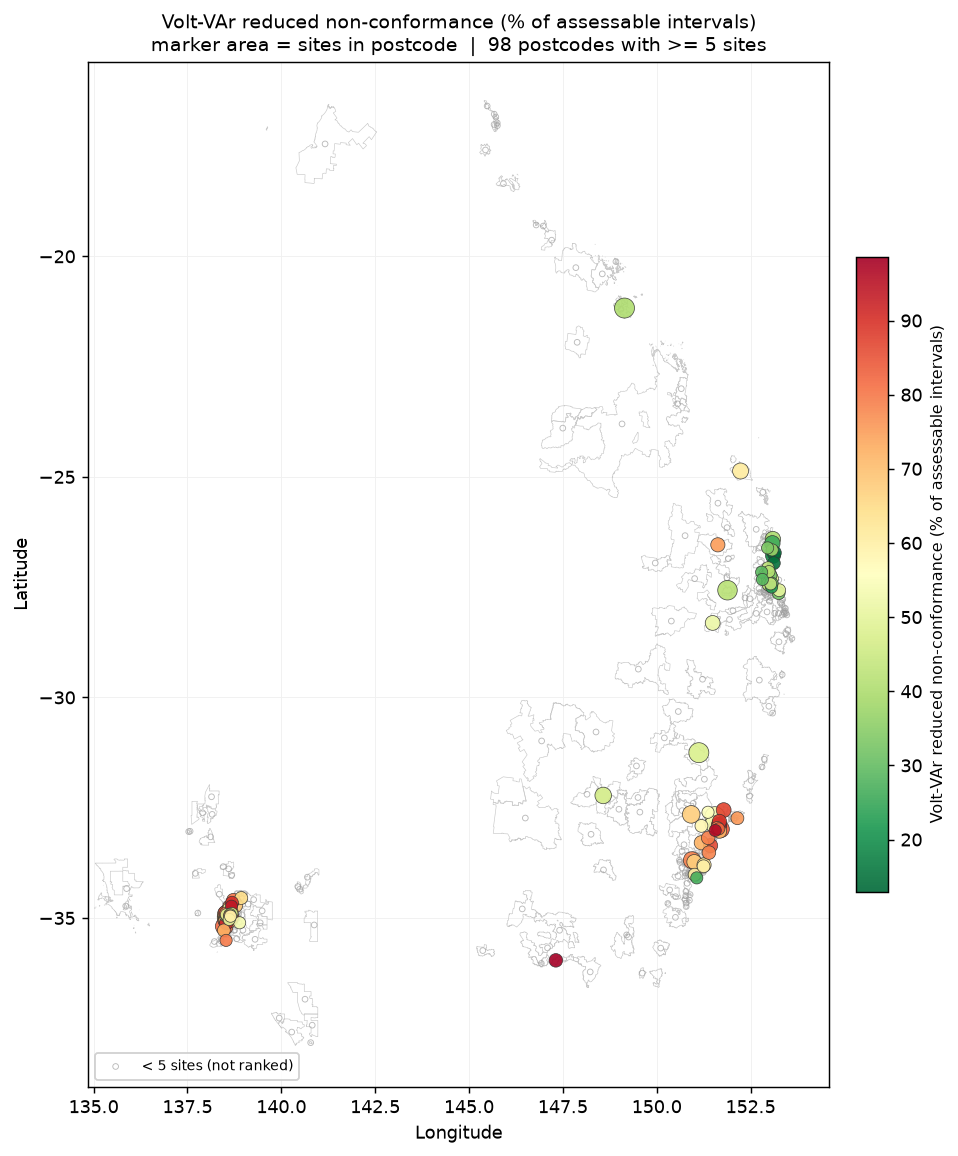

In [10]:
fig = plots.plot_postcode_map(
    con, pc_intervals, "pct_reduced_nonconf", min_sites=5,
    label="Volt-VAr reduced non-conformance (% of assessable intervals)")
display(fig)

The capitals are overlapping clusters at continental scale, so the same data zoomed.

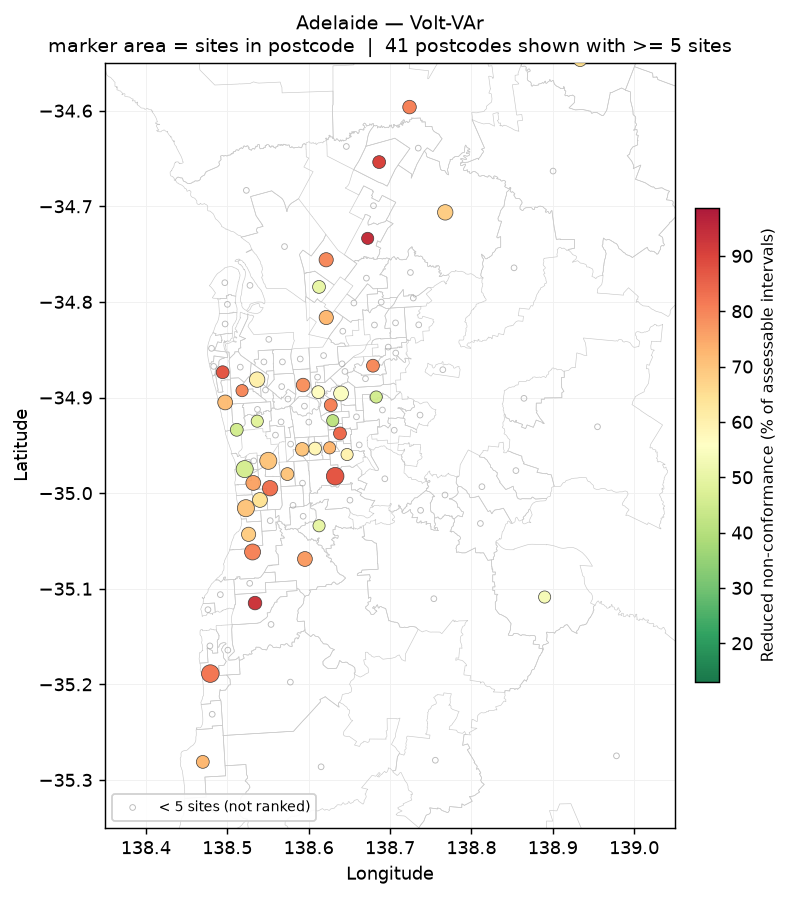

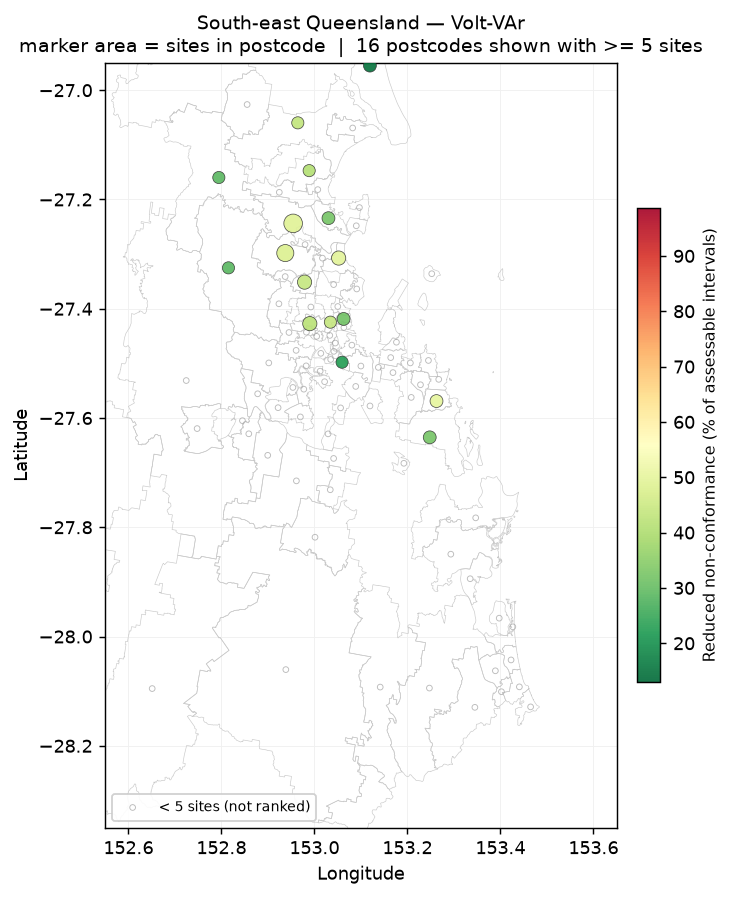

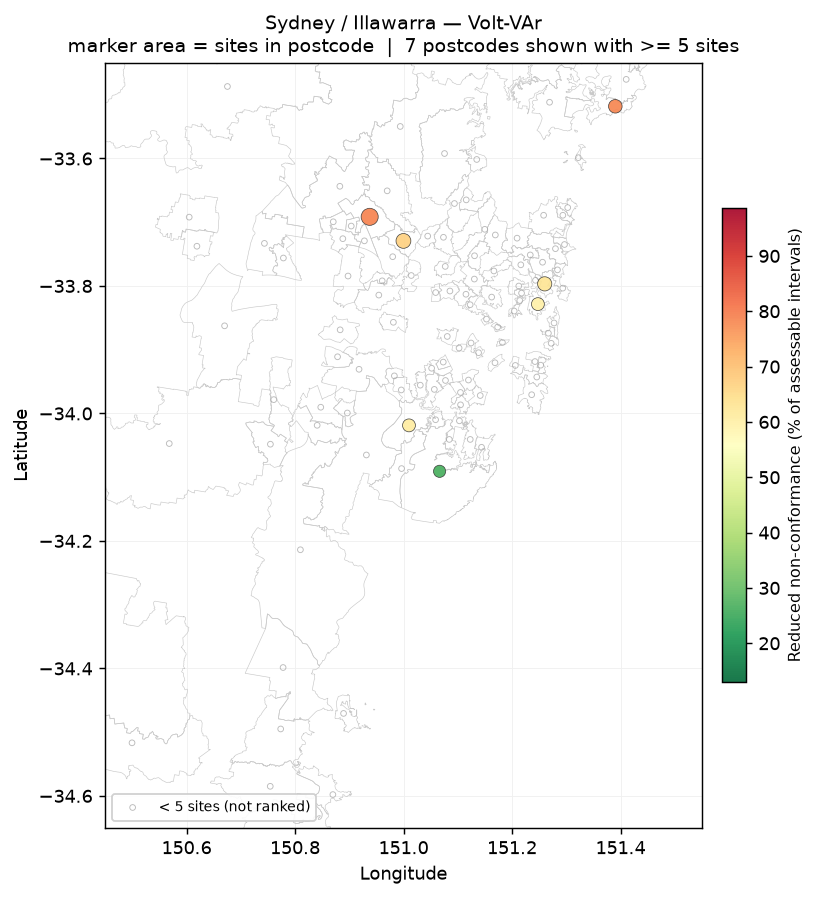

In [11]:
METRO = {
    "Adelaide":              (138.35, 139.05, -35.35, -34.55),
    "South-east Queensland": (152.55, 153.65, -28.35, -26.95),
    "Sydney / Illawarra":    (150.45, 151.55, -34.65, -33.45),
}

# Colour limits come from the national frame, not each panel, so the three zooms
# are comparable with each other and with the map above.
for name, extent in METRO.items():
    display(plots.plot_postcode_map(
        con, pc_intervals, "pct_reduced_nonconf", min_sites=5,
        extent=extent, figsize=(8.0, 7.0),
        label="Reduced non-conformance (% of assessable intervals)",
        title=f"{name} — Volt-VAr"))

#### Is postcode actually explanatory?

The map invites the conclusion that geography drives non-conformance. Before accepting
that, the claim needs testing — and the obvious test is the wrong one.

Regressing the site rate on postcode gives R² ≈ 0.46, which looks decisive. It is an
artefact. **194 of 507 postcodes hold exactly one site**; the median is 2. Where a postcode
has one site, "the postcode effect" and "that site's behaviour" are the same number, and a
507-level categorical fitted to ~1,600 observations has enough free parameters to memorise
the data. Shuffling the postcode labels at random still yields R² ≈ 0.32 — that is the
price of the parameters alone, before any signal.

So every measure below is compared against a **permutation null** that preserves the same
group-size structure and the same capacity to overfit. Three tests, because they answer
different questions and can disagree:

1. **ICC** — are sites in the same postcode alike? A *label* question.
2. **Moran's I** — are *nearby* postcodes alike? A *spatial* question.
3. **Nested R²** — does postcode add anything once state, size and cohort are known?

In [12]:
effect = spat.postcode_effect_report(con, vvar_site_day, config)

1,580 sites with >= 500 assessable intervals (0 dropped as too sparse to rate)
504 postcodes | median 2 site(s) each | 195 with only one

1. CLUSTERING  — are sites in the same postcode alike?
  ICC observed      +0.2004
  ICC under shuffle -0.0002 (95th pct +0.0345)
  permutation p     0.0010
  309 of 504 postcodes have more than one site — only those carry any within-postcode signal.

2. SPATIAL  — are neighbouring postcodes alike?
  Moran's I  +0.3792   (expected under no pattern -0.0032)
  permutation p 0.0010   over 309 multi-site postcodes, k=8

3. INCREMENTAL  — does postcode beat simpler explanations?
                      grouping  n_levels  r2_observed  r2_null_mean  r2_excess  p_value
state + capacity_band + cohort        35       0.1971        0.0212     0.1759    0.005
                      postcode       504       0.4547        0.3183     0.1365    0.005
                         state         3       0.1181        0.0014     0.1168    0.005
                        cohort 

**Reading the result.** The variation is spatially structured and highly significant, but
the scale matters: ~500 postcode parameters buy barely more than 3 state ones
(r²_excess 0.137 vs 0.127). The gradient is **regional, not per-postcode** — consistent
with the static maps, where Adelaide and Sydney run hot while south-east Queensland runs
cool.

Practical consequence: report conformance by **state or metro area**. Per-postcode rates
mostly resolve sampling noise, and the map above should be read as a way of *locating*
sites to inspect, not as a per-postcode measurement.

And none of this is causal. Postcode is a stand-in for network topology, feeder length,
transformer sizing, installer and inverter vintage — none of which are in this dataset.
A postcode effect says "look at the network here", not "the postcode caused it".

#### Interactive map

Rate as colour, **installs as circle area**, both in the tooltip — so a lurid red circle
backed by two sites is immediately identifiable as noise rather than a finding, which is
exactly the confusion the static map cannot prevent.

Needs `folium` (`conda install -c conda-forge folium`). Saved to `artefacts/` as
standalone HTML you can send to someone without the repo.

In [13]:
imap = spat.interactive_postcode_map(
    con, pc_intervals, "pct_reduced_nonconf",
    min_sites=1,                       # show everything; size encodes the caveat
    label="Volt-VAr reduced non-conformance",
    out_path=C.ARTEFACT_DIR / "voltvar_postcode_map.html",
)
# imap

Interactive map -> C:\Users\z3553082\OneDrive - UNSW\Documents\GitHub\CICCADA\solar_edge\artefacts\voltvar_postcode_map.html


## 4. Unpacking the adverse results

`Q_adverse` means the inverter moved reactive power in the **wrong direction**: Supplying where the curve requires absorption.

The triage uses **magnitude**, which is orientation-independent:

| class | meaning | safe to report as non-conformance? |
|---|---|---|
| `polarity_suspect` | adverse in direction, but \|Q\| tracks the required curve within ±4% | **No**: Might be a data-format finding |
| `genuinely_adverse` | adverse in direction, magnitude does not match the curve | **Yes**: adverse under either orientation |
| `adverse_but_inactive` | adverse in direction, delivering < 25% of requirement | **No**: direction of a near-zero quantity |
| `not_adverse` | absorbing, or near zero | — |

This is **triage, not a correction.** Flipping the polarity-suspect sites and re-scoring
would infer the sign from conformity with the curve and then report conformity with the
curve.

In [14]:
adverse = adv.classify_adverse_sites(con, config)
display(pd.crosstab(adverse.adverse_class, adverse.cohort, margins=True))
display(adv.adverse_summary(adverse))

cohort,single-phase,three-phase,All
adverse_class,,,
adverse_but_inactive,612,1,613
genuinely_adverse,311,4,315
not_adverse,145,401,546
polarity_suspect,108,1,109
All,1176,407,1583


,adverse_class,cohort,n_sites,median_ratio,median_s_99,interpretation
0,adverse_but_inactive,single-phase,612,0.169,5.01,barely responding; direction uninformative -- ...
1,adverse_but_inactive,three-phase,1,0.215,8.31,barely responding; direction uninformative -- ...
2,genuinely_adverse,single-phase,311,0.331,5.01,substantial response in the wrong direction --...
3,genuinely_adverse,three-phase,4,0.369,8.36,substantial response in the wrong direction --...
4,not_adverse,single-phase,145,1.070,5.01,absorbing (or near zero) in the configured ori...
5,not_adverse,three-phase,401,0.398,8.27,absorbing (or near zero) in the configured ori...
6,polarity_suspect,single-phase,108,0.580,5.01,follows the curve in magnitude; sign reported ...
7,polarity_suspect,three-phase,1,1.301,8.20,follows the curve in magnitude; sign reported ...


### Where the adverse intervals actually come from

Site counts and interval counts tell different stories. This attributes every
`Q_adverse` interval to its site's class, which turns "the adverse rate may be
contaminated" into a number.

In [15]:
impact_tbl = adv.adverse_conformance_impact(con, adverse, config, params)
impact_tbl["pct_of_all_adverse"] = (
    100 * impact_tbl.adverse_intervals / impact_tbl.adverse_intervals.sum()).round(2)
display(impact_tbl)

adverse.to_csv(C.ARTEFACT_DIR / "adverse_classification.csv", index=False)
print(f"Per-site classification -> {C.ARTEFACT_DIR / 'adverse_classification.csv'}")

,adverse_class,assessable_intervals,adverse_intervals,n_sites,pct_of_all_adverse
0,adverse_but_inactive,19481148,15806063,605,68.54
1,genuinely_adverse,9876898,6143930,309,26.64
2,polarity_suspect,3457294,800253,108,3.47
3,not_adverse,17308886,310470,541,1.35
4,unclassified,573061,597,17,0.00


Per-site classification -> C:\Users\z3553082\OneDrive - UNSW\Documents\GitHub\CICCADA\solar_edge\artefacts\adverse_classification.csv


### Per-site table

One row per site with its category percentages, so you can pick sites to inspect rather
than guess. Percentages are against **that site's own** capability-assessable intervals,
which puts a 200-interval site and a 200,000-interval site on the same scale — so
`assessable_intervals` is carried alongside, because a 100% rate on a handful of
intervals is not a finding.

`adverse_class` is joined from the triage in section 4, so polarity-suspect sites can be inspected first or set aside.

Take any `site_alias` from this table into `05_site_explorer.ipynb`:

```python
from solar_edge.lib import se_explore as ex
ex.site_profile(con, "AUS978")
ex.plot_site_voltvar_curve(ex.site_voltvar_curve(con, "AUS978"), "AUS978")
```

In [16]:
vvar_sites = cf.voltvar_site_table(con, vvar_site_day, config, adverse=adverse)
display(vvar_sites.verdict.value_counts())

print("\nWorst 15 by reduced non-conformance:")
display(vvar_sites.head(15))

print("Best 15 (conformant, most-observed first):")
display(vvar_sites[vvar_sites.verdict == "conformant"]
        .nlargest(15, "assessable_intervals"))

vvar_sites.to_csv(C.ARTEFACT_DIR / "voltvar_by_site.csv", index=False)
print(f"\n-> {C.ARTEFACT_DIR / 'voltvar_by_site.csv'}  ({len(vvar_sites):,} sites)")

# The Volt-Watt site table needs vwatt_site_day, which is built in section 5.
# It is written there rather than here.

verdict
non-conformant    1286
conformant         294
Name: count, dtype: int64


Worst 15 by reduced non-conformance:


,site_alias,cohort,state,postcode,s_99,capacity_band,n_days,all_intervals,exposed_intervals,assessable_intervals,verdict,pct_reduced_nonconf,pct_Q_adverse,pct_Q_inactive,pct_Q_significant_shortfall,pct_Q_near_conformant,pct_Q_major_surplus,curtailment_eligible,derating_intervals,adverse_class,ratio_to_required
1558,AUS978,single-phase,New South Wales,2640,4.646416,4-5,365,53971,53971.0,35053.0,non-conformant,100.000,83.619,16.381,0.000,0.0,0.000,0.0,8316,adverse_but_inactive,0.107
594,AUS1456,single-phase,New South Wales,2640,4.381326,4-5,365,52426,52420.0,34301.0,non-conformant,100.000,94.003,5.997,0.000,0.0,0.000,0.0,14822,adverse_but_inactive,0.137
703,AUS1556,single-phase,Queensland,4879,4.955341,4-5,266,39061,39061.0,25014.0,non-conformant,100.000,93.396,6.604,0.000,0.0,0.000,0.0,7225,adverse_but_inactive,0.113
746,AUS1597,single-phase,South Australia,5000,4.996740,4-5,85,14339,14339.0,9468.0,non-conformant,100.000,99.155,0.845,0.000,0.0,0.000,0.0,2843,adverse_but_inactive,0.144
1272,AUS688,single-phase,Queensland,4878,5.950645,5-6,365,54073,54073.0,33263.0,non-conformant,100.000,21.907,78.093,0.000,0.0,0.000,0.0,10841,adverse_but_inactive,0.077
1293,AUS709,single-phase,New South Wales,2714,5.003524,5-6,365,53901,53901.0,35438.0,non-conformant,100.000,63.850,36.150,0.000,0.0,0.000,0.0,8631,adverse_but_inactive,0.094
1170,AUS584,single-phase,New South Wales,2640,5.655075,5-6,365,52673,52673.0,34650.0,non-conformant,100.000,58.260,41.740,0.000,0.0,0.000,0.0,7285,adverse_but_inactive,0.090
990,AUS403,single-phase,New South Wales,2640,4.796251,4-5,365,54390,54390.0,34636.0,non-conformant,100.000,99.255,0.745,0.000,0.0,0.000,0.0,6618,adverse_but_inactive,0.125
1059,AUS472,single-phase,Queensland,4869,4.847531,4-5,365,54259,54259.0,32510.0,non-conformant,100.000,59.366,40.634,0.000,0.0,0.000,0.0,9819,adverse_but_inactive,0.094
1054,AUS467,single-phase,New South Wales,2250,5.999284,5-6,365,53875,53875.0,29800.0,non-conformant,100.000,41.144,58.856,0.000,0.0,0.000,0.0,7485,adverse_but_inactive,0.084


Best 15 (conformant, most-observed first):


,site_alias,cohort,state,postcode,s_99,capacity_band,n_days,all_intervals,exposed_intervals,assessable_intervals,verdict,pct_reduced_nonconf,pct_Q_adverse,pct_Q_inactive,pct_Q_significant_shortfall,pct_Q_near_conformant,pct_Q_major_surplus,curtailment_eligible,derating_intervals,adverse_class,ratio_to_required
1061,AUS474,single-phase,Queensland,4670,5.012042,5-6,365,54383,38.0,39305.0,conformant,0.000,0.000,0.0,0.000,2.939,58.328,0.0,5459,NaN,NaN
1014,AUS427,single-phase,Queensland,4655,5.007264,5-6,365,54854,12078.0,39169.0,conformant,0.000,0.000,0.0,0.000,3.738,0.970,395.0,4951,not_adverse,1.349
1089,AUS502,single-phase,Queensland,4370,5.004149,5-6,365,54260,1859.0,38498.0,conformant,0.727,0.727,0.0,0.000,0.239,1.805,0.0,2033,polarity_suspect,0.573
1218,AUS633,single-phase,Queensland,4701,5.008940,5-6,365,55148,54954.0,37868.0,conformant,0.003,0.000,0.0,0.003,0.045,0.029,520.0,15777,not_adverse,1.029
486,AUS1358,single-phase,Queensland,4509,5.009160,5-6,357,53241,13148.0,37668.0,conformant,7.978,7.978,0.0,0.000,14.198,30.803,0.0,3480,polarity_suspect,0.549
581,AUS1444,single-phase,New South Wales,2360,4.989221,4-5,365,54628,6213.0,37652.0,conformant,5.434,5.434,0.0,0.000,1.509,6.929,0.0,6784,polarity_suspect,0.611
1002,AUS415,single-phase,Queensland,4019,8.010714,8-10,364,54170,31948.0,37506.0,conformant,0.189,0.000,0.0,0.189,1.250,0.640,507.0,9072,not_adverse,1.040
738,AUS159,three-phase,New South Wales,2830,8.199164,8-10,365,55070,2589.0,37498.0,conformant,0.605,0.605,0.0,0.000,8.944,8.123,0.0,335,polarity_suspect,1.301
563,AUS1428,single-phase,South Australia,5095,4.622501,4-5,365,54919,49923.0,37337.0,conformant,0.000,0.000,0.0,0.000,0.260,0.021,499.0,4854,not_adverse,1.181
227,AUS1118,single-phase,Queensland,4503,5.005745,5-6,364,54568,28862.0,37165.0,conformant,5.188,5.188,0.0,0.000,0.409,1.684,368.0,4041,not_adverse,1.094



-> C:\Users\z3553082\OneDrive - UNSW\Documents\GitHub\CICCADA\solar_edge\artefacts\voltvar_by_site.csv  (1,580 sites)


## 5. Volt-Watt conformance

### 5a. Volt-Watt maximum-output conformance:

> **Question:** when voltage selected a reduced maximum active-power level, did measured P exceed that permitted maximum (including the ±4% band)?

A site is *exposed* above 253 V, and non-conformant when measured P exceeds the Volt-Watt ceiling plus tolerance.
A below-ceiling observation satisfies this maximum-output test but does **not**, by itself, demonstrate active curtailment.

### 5b. Volt-Watt response-supported result:

> **Question:** was enough solar power available to test the response, or was a violation directly observed?

Port of `conformance_voltwattghi` from `Volt-Watt-ghi.ipynb`. An exposed interval counts in the denominator when

```
uncurtailed_P > max_P_volt_watt   OR   uncurtailed_P IS NULL
```

Two outputs:

| column | meaning |
|---|---|
| `nonconformance` | kW generated **above** the ceiling — a violation |
| `curtailment` | kW available but not generated while staying below the ceiling — **evidence of correct response**, not a fault |

Requires `se_uncurtailedpv`.

In [17]:
vwatt_site_day = cf.voltwatt_site_day(con, config)
vwatt_summary = cf.voltwatt_summary(vwatt_site_day, by_cohort=True)
display(vwatt_summary.T)

vwatt_verdicts = cf.voltwatt_site_verdicts(vwatt_site_day, config)
display(pd.crosstab(
    vwatt_verdicts.is_three_phase.map({False: "single-phase", True: "three-phase"}),
    vwatt_verdicts.verdict, margins=True))

,0,1
cohort,single-phase,three-phase
n_sites,1165,415
sites_exposed,503,70
all_intervals,61526522,23763800
exposed_intervals,631154,4285
nonconformant_intervals,124676,41
nonconformant_pct_of_exposed,19.753658,0.956826
excess_kWh,5585.857452,1.183588
exposed_with_derating_flag,456420,1779


verdict,conformant,non-conformant,not exposed,All
is_three_phase,,,,
single-phase,402,101,662,1165
three-phase,62,8,345,415
All,464,109,1007,1580


### Volt-Watt site verdicts

- the denominator is **exposed** intervals (V > 253 V). 
- Volt-Watt has no 20%-of-rating floor (like voltvar), but a site that never saw high voltage was never tested.
- hence the third verdict, `not exposed`, which is **not** a pass.
- the energy is **kWh generated above the ceiling**, not kVArh of missing reactive power.
- Volt-Watt non-conformance means producing too much, so the quantity is real energy that should not have been generated (exported?).

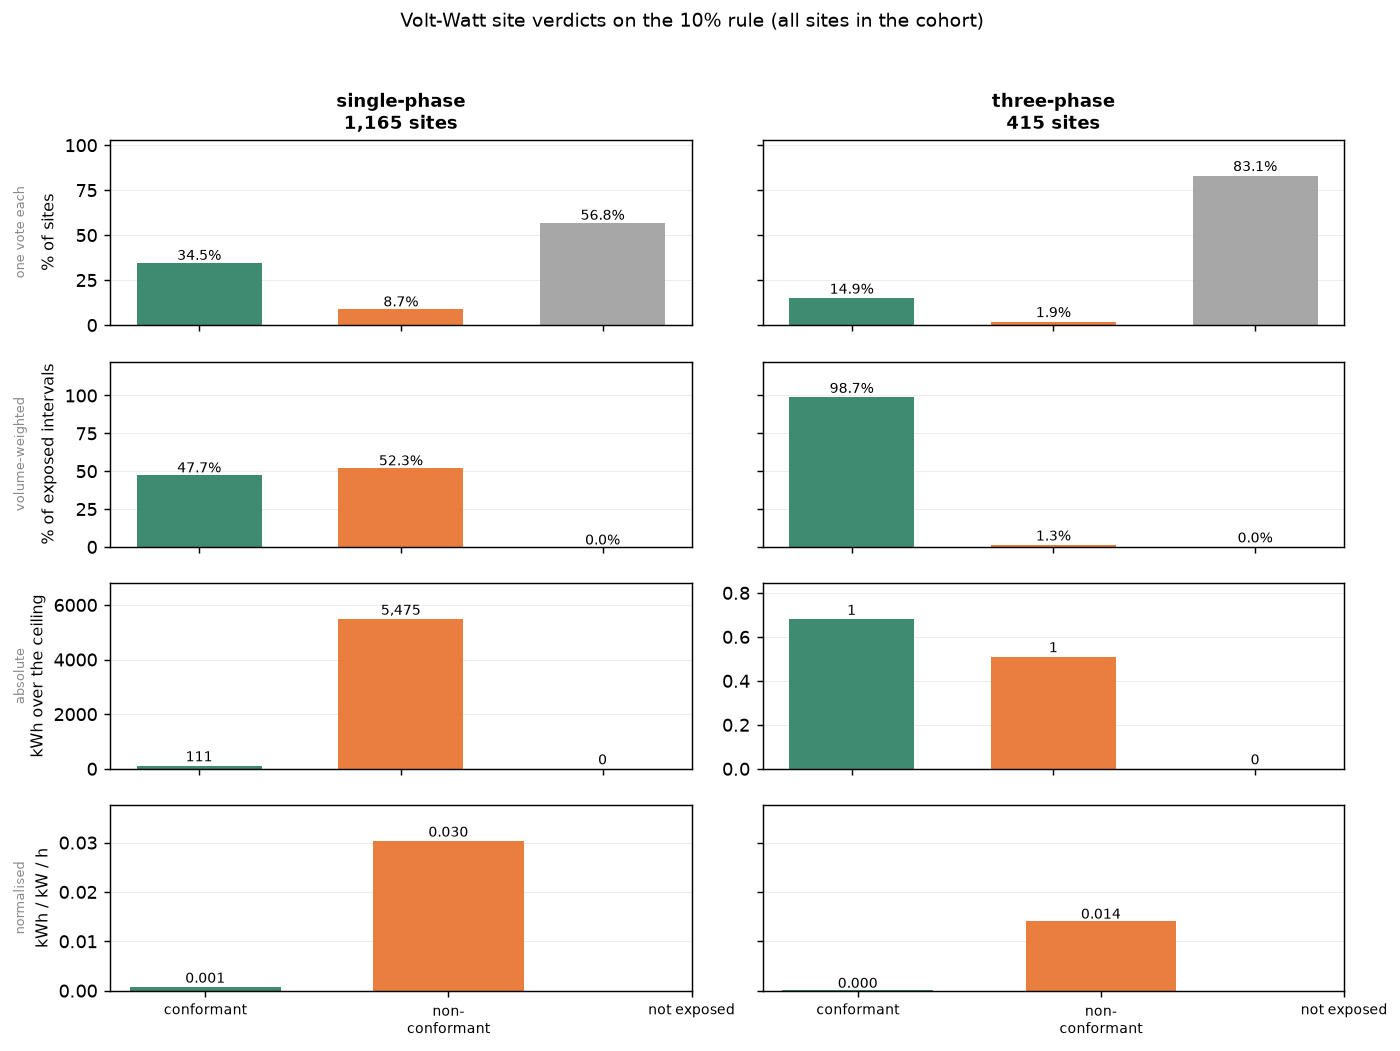

,cohort,denominator,verdict,n_sites,pct_sites,pct_intervals,kwh,kwh_per_kw_per_h
0,single-phase,all,conformant,402,34.506,47.674,110.61,0.00071
1,single-phase,all,non-conformant,101,8.670,52.326,5475.25,0.03030
2,single-phase,all,not exposed,662,56.824,0.000,0.00,NaN
3,three-phase,all,conformant,62,14.940,98.740,0.68,0.00016
4,three-phase,all,non-conformant,8,1.928,1.260,0.51,0.01417
5,three-phase,all,not exposed,345,83.133,0.000,0.00,NaN


In [18]:
# `denominator="all"` keeps never-exposed sites visible as their own category.
vwatt_verdict_measures = cf.voltwatt_verdict_measures(
    vwatt_site_day, config, denominator="all")
display(plots.plot_site_verdicts(vwatt_verdict_measures, config,
                                 measures=cf.VW_VERDICT_MEASURES, mode="Volt-Watt",
                                 denominator="all sites in the cohort"))
display(vwatt_verdict_measures)

#### Denominator conventions: Volt-Watt

**Which sites belong in the denominator?** 

| convention | denominator | question |
|---|---|---|
| `assessed` | sites with ≥ 1 interval in the assessment population | *of the inverters actually tested, how many passed?* |
| `all` | every site in the cohort | *what share of the fleet has demonstrated conformance?* |

- `assessed` is what's in the Milestone report #3 
- In (`Volt-Watt-Trino.ipynb`) the build carries `HAVING avg(voltage) > 253`, so a site that never saw high voltage produces **no rows at all** and cannot reach any downstream rate

In [19]:
vwatt_denominators = cf.denominator_comparison(vwatt_site_day, "voltwatt", config)
display(vwatt_denominators.drop(columns="denominator_intervals"))
cf.denominator_note(vwatt_denominators)

,mode,cohort,n_sites_in_table,n_assessed_sites,n_not_exposed,pct_excluded,pct_conformant_assessed,pct_nonconformant_assessed,pct_conformant_all,pct_nonconformant_all
0,Volt-Watt,single-phase,1165,503,662,56.824,79.920,20.080,34.506,8.670
1,Volt-Watt,three-phase,415,70,345,83.133,88.571,11.429,14.940,1.928
2,Volt-Watt,all sites,1580,573,1007,63.734,80.977,19.023,29.367,6.899


Volt-Watt — the same sites, two defensible denominators:

  assessed only :  81.0% conformant of 573 tested sites
                  -> comparable with the Solar Analytics study
  whole cohort  :  29.4% conformant of 1,580 sites
                  -> 63.7% were never tested at all

  Neither counts a never-tested site as conformant. Doing so would give
  93.1%, which would mostly measure the absence of exposure.


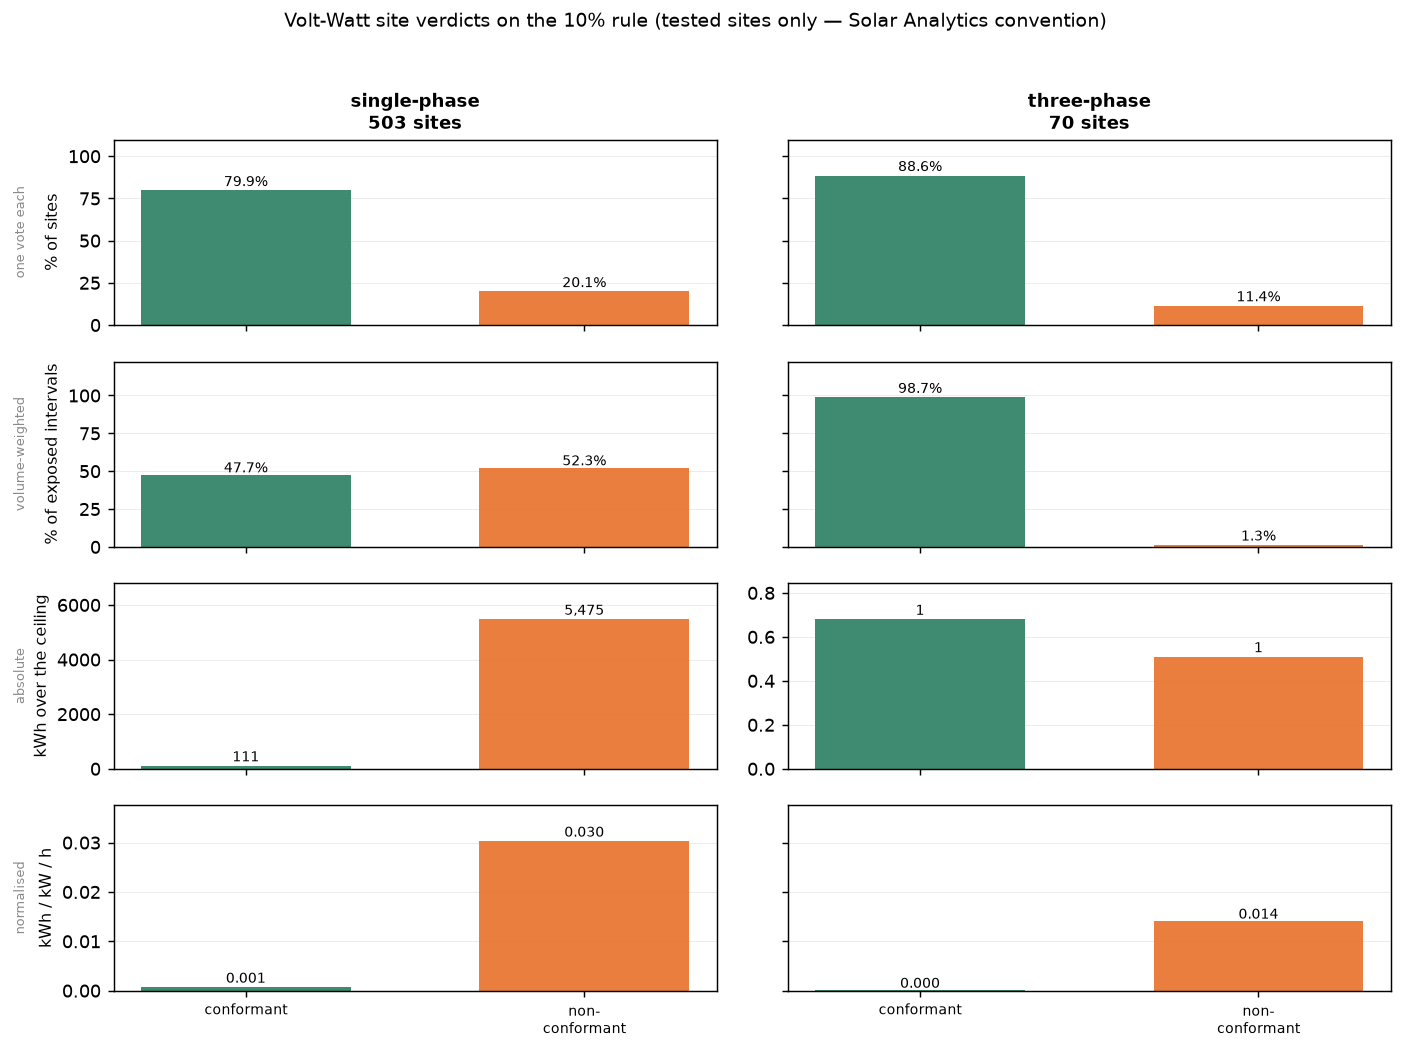

,cohort,denominator,verdict,n_sites,pct_sites,pct_intervals,kwh,kwh_per_kw_per_h
0,single-phase,assessed,conformant,402,79.920,47.674,110.61,0.00071
1,single-phase,assessed,non-conformant,101,20.080,52.326,5475.25,0.03030
2,three-phase,assessed,conformant,62,88.571,98.740,0.68,0.00016
3,three-phase,assessed,non-conformant,8,11.429,1.260,0.51,0.01417


In [20]:
vwatt_measures_assessed = cf.voltwatt_verdict_measures(
    vwatt_site_day, config, denominator="assessed")
display(plots.plot_site_verdicts(
    vwatt_measures_assessed, config, measures=cf.VW_VERDICT_MEASURES,
    mode="Volt-Watt", denominator="tested sites only — Solar Analytics convention"))
display(vwatt_measures_assessed)

In [21]:
vwatt_sites = cf.voltwatt_site_table(con, vwatt_site_day, config)
display(vwatt_sites.head(10))

vwatt_sites.to_csv(C.ARTEFACT_DIR / "voltwatt_by_site.csv", index=False)
print(f"-> {C.ARTEFACT_DIR / 'voltwatt_by_site.csv'} ({len(vwatt_sites):,} sites)")

,site_alias,state,postcode,is_three_phase,s_99,capacity_band,all_intervals,exposed_intervals,nonconformant_intervals,excess_kW_sum,exposed_with_derating,pct_nonconformant_of_exposed,excess_Wh,severity_Wh_per_kVA_per_exposed,verdict,cohort
1431,AUS849,New South Wales,2831,False,5.711915,5-6,54261,1,1,1.813689,0,100.000,151.140726,26.460604,non-conformant,single-phase
96,AUS099,Queensland,4208,False,6.014281,6-8,53547,1,1,0.179096,1,100.000,14.924625,2.481531,non-conformant,single-phase
421,AUS1299,New South Wales,2768,False,4.989688,4-5,54586,1,1,0.119979,1,100.000,9.998279,2.003789,non-conformant,single-phase
525,AUS1393,Queensland,4122,True,9.952523,8-10,55654,1,1,0.302783,0,100.000,25.231908,2.535227,non-conformant,three-phase
452,AUS1327,New South Wales,2769,True,7.008192,6-8,33769,1,1,0.132570,1,100.000,11.047474,1.576366,non-conformant,three-phase
255,AUS1143,Queensland,4573,False,5.661398,5-6,54832,23,16,20.376851,18,69.565,1698.070958,13.040802,non-conformant,single-phase
739,AUS1590,New South Wales,2325,False,8.158480,8-10,19310,4800,3308,3641.289505,3304,68.917,303440.792087,7.748604,non-conformant,single-phase
572,AUS1436,Queensland,4073,False,7.169655,6-8,53264,30,19,17.032238,25,63.333,1419.353205,6.598892,non-conformant,single-phase
670,AUS1526,Queensland,4034,False,6.311652,6-8,53781,3997,2485,1559.784885,2425,62.172,129982.073747,5.152361,non-conformant,single-phase
238,AUS1128,New South Wales,2282,False,8.256674,8-10,53911,8276,5079,5486.000327,5624,61.370,457166.693878,6.690352,non-conformant,single-phase


-> C:\Users\z3553082\OneDrive - UNSW\Documents\GitHub\CICCADA\solar_edge\artefacts\voltwatt_by_site.csv (1,580 sites)


### Volt-Watt breakdowns

- Same two-frame structure as Volt-VAr. Note the interval denominator here is **exposed** intervals (V > 253 V).
- `severity_Wh_per_kVA_per_exposed` is the normalised magnitude metric: nonconformance Wh ÷ (capacity × exposed intervals). 
- Frequency says how *often*; severity says how far *over*. It does not replace the 10% classification.


STATE — % of SITES by verdict (10% rule)


,site_state,n_sites,pct_sites_conformant,pct_sites_non_conformant,pct_sites_not_exposed
0,New South Wales,560,35.89,11.96,52.14
1,Queensland,452,24.34,5.53,70.13
2,South Australia,568,26.94,2.99,70.07


STATE — exposure, non-conformance and severity


,site_state,n_sites,sites_exposed,exposed_intervals,nonconformant_intervals,excess_Wh,capacity_exposure,pct_intervals_nonconformant,severity_Wh_per_kVA_per_exposed
0,New South Wales,560,268,247748,64476,3.711798e+06,1.602692e+06,26.025,2.315977
2,South Australia,568,170,209337,35081,8.578512e+05,1.115997e+06,16.758,0.768686
1,Queensland,452,135,178354,25160,1.017391e+06,1.151966e+06,14.107,0.883178


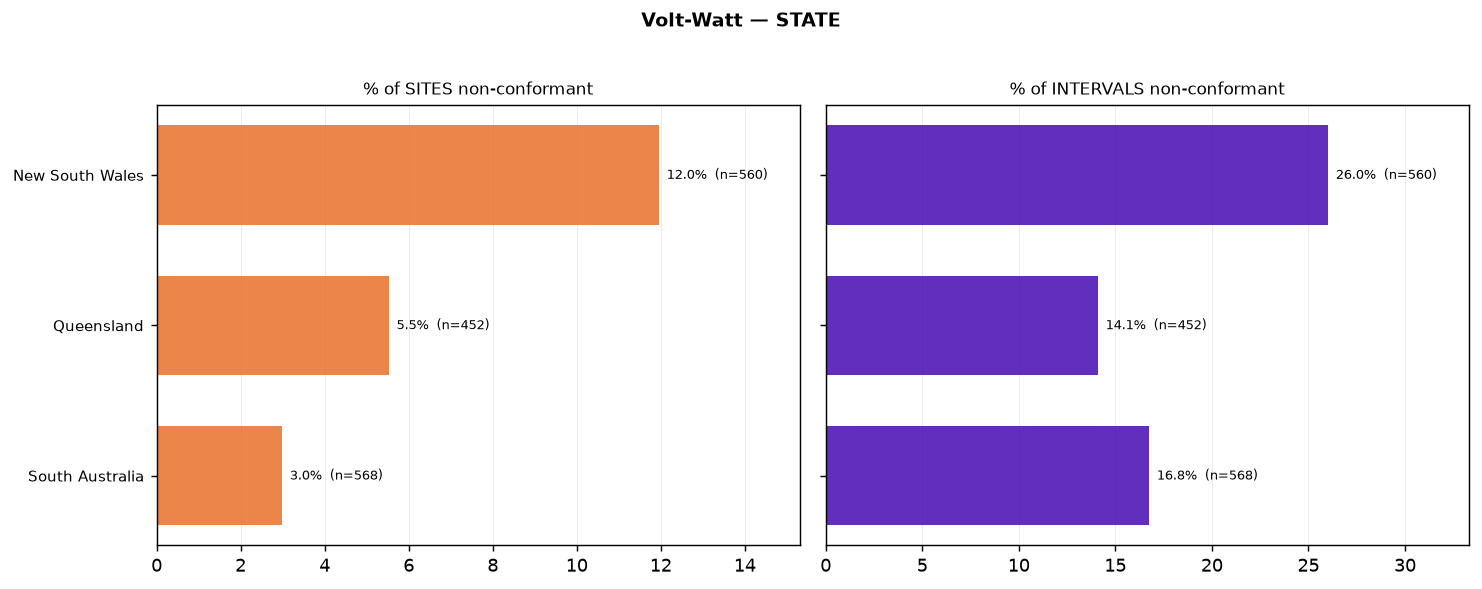


SYSTEM SIZE (s_99, kVA) — % of SITES by verdict (10% rule)


,capacity_band,n_sites,pct_sites_conformant,pct_sites_non_conformant,pct_sites_not_exposed
0,<3,2,0.00,0.00,100.00
1,3-4,15,33.33,6.67,60.00
2,4-5,353,35.69,8.22,56.09
3,5-6,486,29.84,3.91,66.26
4,6-8,348,28.45,9.48,62.07
5,8-10,262,24.81,9.54,65.65
6,>10,114,21.05,1.75,77.19


SYSTEM SIZE (s_99, kVA) — exposure, non-conformance and severity


,capacity_band,n_sites,sites_exposed,exposed_intervals,nonconformant_intervals,excess_Wh,capacity_exposure,pct_intervals_nonconformant,severity_Wh_per_kVA_per_exposed
0,<3,2,0,0,0,0.000000e+00,0.000000e+00,NaN,NaN
1,3-4,15,6,10280,1532,6.702996e+04,3.715789e+04,14.903,1.803923
2,4-5,353,155,228167,39496,8.684136e+05,1.062890e+06,17.310,0.817031
3,5-6,486,164,139635,15691,3.669856e+05,7.559611e+05,11.237,0.485456
4,6-8,348,132,147847,44431,2.812437e+06,1.049867e+06,30.052,2.678851
5,8-10,262,90,101052,23505,1.470332e+06,8.748918e+05,23.260,1.680587
6,>10,114,26,8458,62,1.842841e+03,8.988785e+04,0.733,0.020502


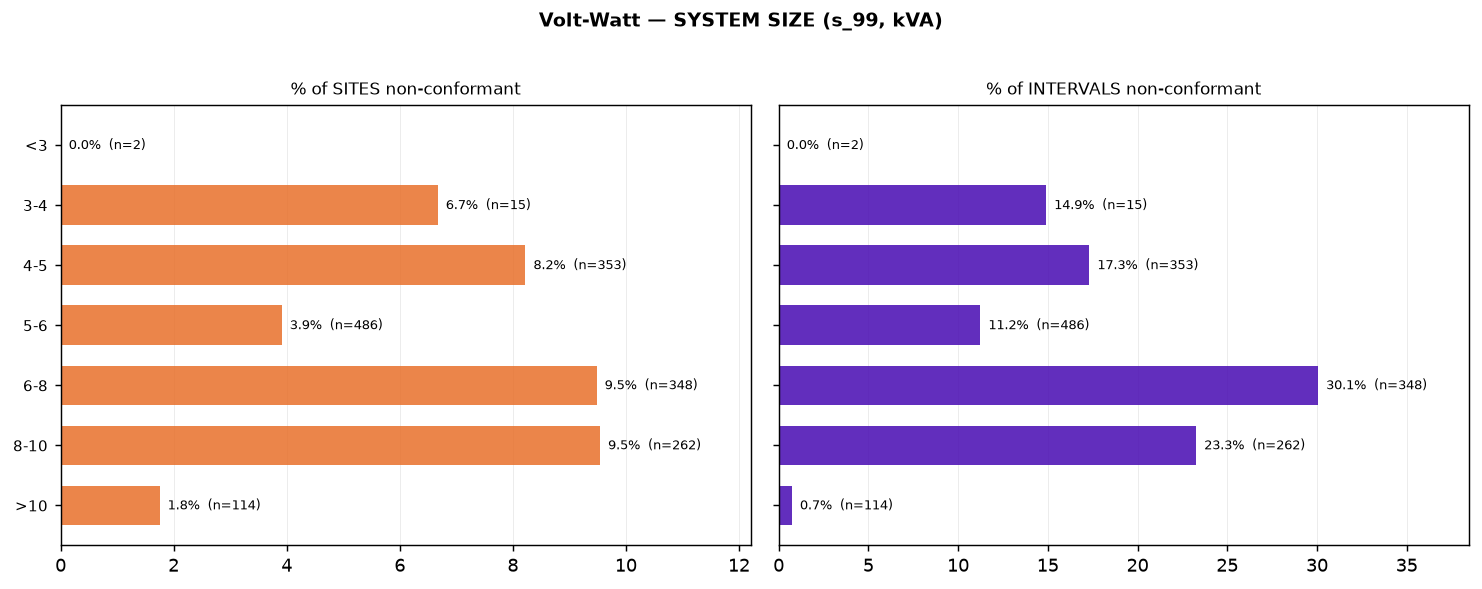


PHASE COHORT — % of SITES by verdict (10% rule)


,cohort,n_sites,pct_sites_conformant,pct_sites_non_conformant,pct_sites_not_exposed
0,single-phase,1165,34.51,8.67,56.82
1,three-phase,415,14.94,1.93,83.13


PHASE COHORT — exposure, non-conformance and severity


,cohort,n_sites,sites_exposed,exposed_intervals,nonconformant_intervals,excess_Wh,capacity_exposure,pct_intervals_nonconformant,severity_Wh_per_kVA_per_exposed
0,single-phase,1165,503,631154,124676,5.585857e+06,3.827648e+06,19.754,1.459344
1,three-phase,415,70,4285,41,1.183588e+03,4.300708e+04,0.957,0.027521


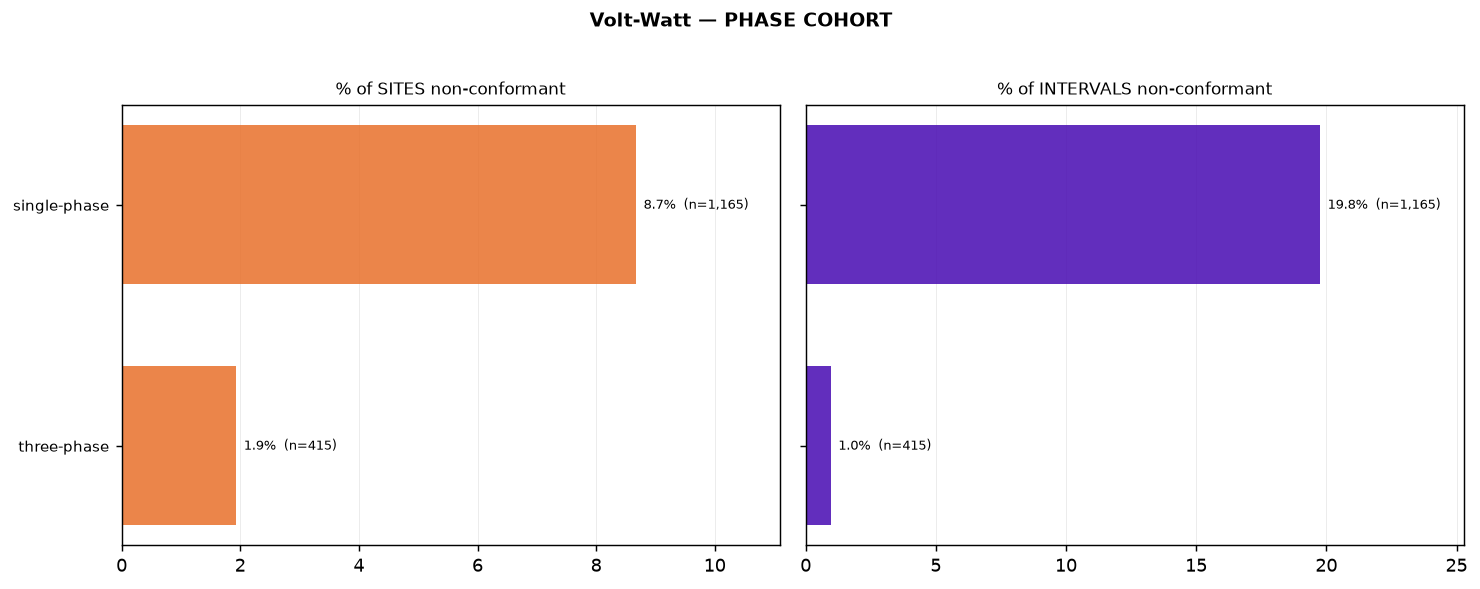

In [22]:
for dimension, label in [("site_state", "STATE"),
                         ("capacity_band", "SYSTEM SIZE (s_99, kVA)"),
                         ("cohort", "PHASE COHORT")]:
    site_pct, interval_pct = cf.voltwatt_breakdown(con, vwatt_site_day, by=dimension,
                                                   config=config)
    print(f"\n{'=' * 100}\n{label} — % of SITES by verdict (10% rule)\n{'=' * 100}")
    display(site_pct)
    print(f"{label} — exposure, non-conformance and severity")
    display(interval_pct)
    display(plots.plot_breakdown_rates(
        site_pct, interval_pct, dimension, "pct_intervals_nonconformant",
        label=f"Volt-Watt — {label}"))

In [23]:
pc_sites_vw, pc_intervals_vw = cf.voltwatt_breakdown(con, vwatt_site_day, by="postcode",
                                                     config=config)
big_vw = pc_intervals_vw[pc_intervals_vw.sites_exposed >= 5]
print(f"{len(pc_intervals_vw):,} postcodes; {len(big_vw):,} with >= 5 exposed sites\n")
display(big_vw.nlargest(10, "pct_intervals_nonconformant"))
pc_intervals_vw.to_csv(C.ARTEFACT_DIR / "voltwatt_by_postcode.csv", index=False)

504 postcodes; 17 with >= 5 exposed sites



,postcode,n_sites,sites_exposed,exposed_intervals,nonconformant_intervals,excess_Wh,capacity_exposure,pct_intervals_nonconformant,severity_Wh_per_kVA_per_exposed
122,2322,8,8,504,246,9105.630709,3046.962848,48.810,2.988429
120,2320,20,7,7406,3530,207091.968403,63138.724312,47.664,3.279952
172,2640,7,7,22193,8006,231257.105928,109704.989602,36.074,2.107991
382,5043,10,5,11667,2812,52929.943150,59581.976153,24.102,0.888355
393,5062,14,6,14892,3248,70832.953506,109067.518182,21.810,0.649441
377,5038,13,6,8670,1446,21309.318379,40041.730740,16.678,0.532178
331,4740,28,8,10265,1552,102181.881100,81115.232275,15.119,1.259713
84,2234,6,6,31,4,80.984025,180.336319,12.903,0.449072
130,2335,5,5,5570,633,14394.092075,28730.046367,11.364,0.501012
102,2287,10,10,6381,706,8340.153042,43870.304941,11.064,0.190109


### 5b: Response supported

,0,1
cohort,single-phase,three-phase
n_sites,503,70
exposed_intervals,631154,4285
counterfactual_covered,604571,3866
pct_covered,95.788,90.222
response_supported_intervals,220960,587
supported_by_model,194377,168
pct_supported_by_model,30.797,3.921
nonconformant_intervals,124676,41
pct_nonconformant_of_supported,56.425,6.985


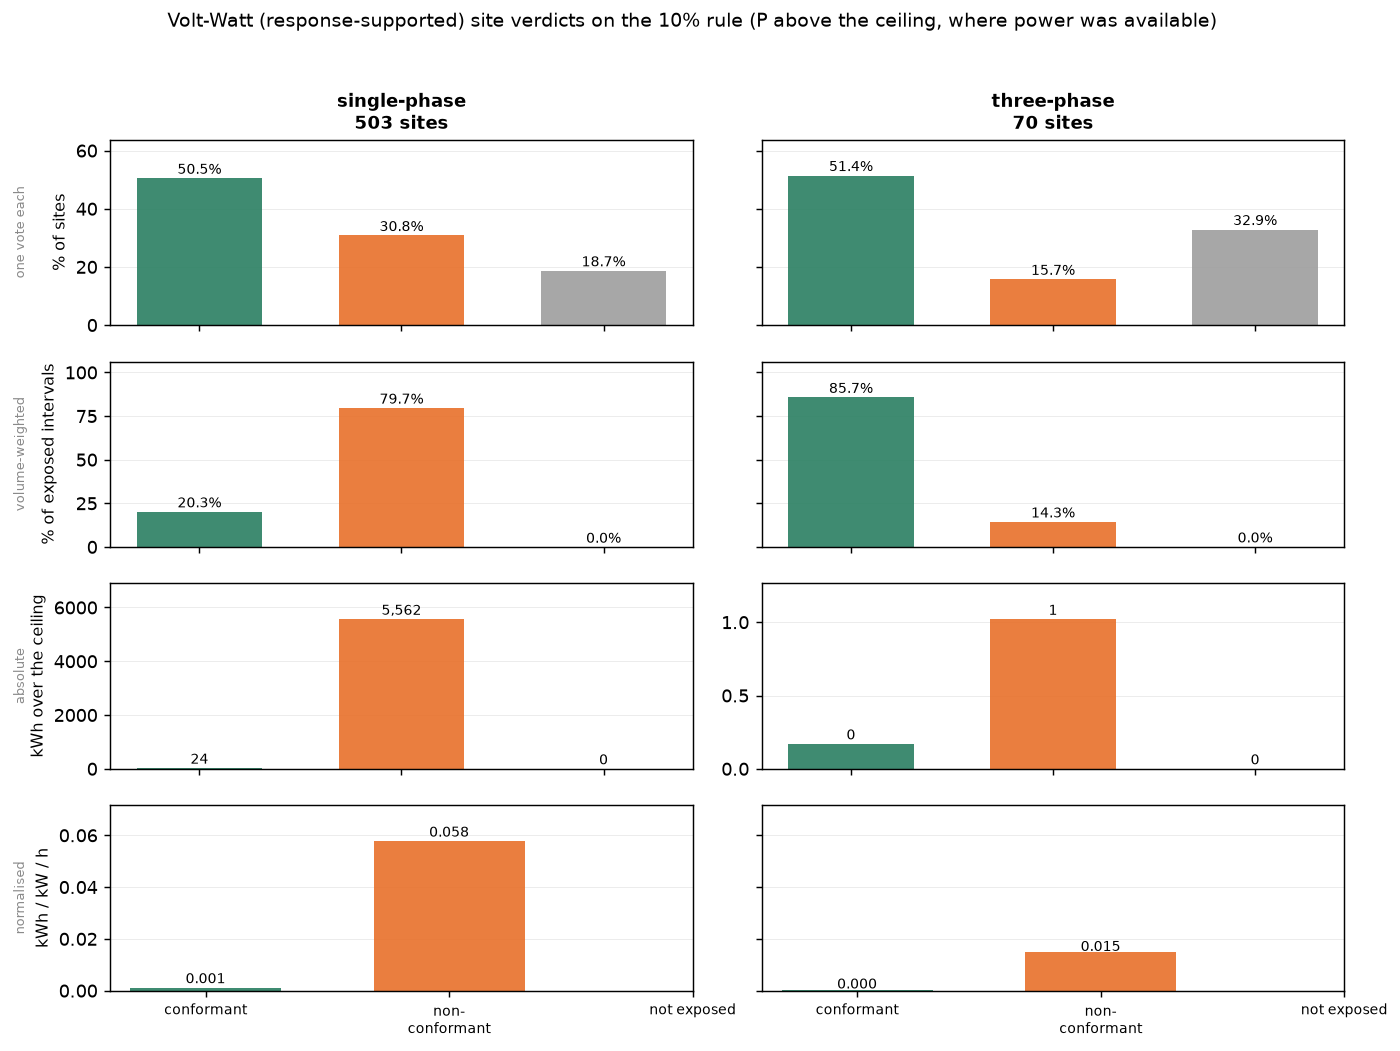

,cohort,denominator,verdict,n_sites,pct_sites,pct_intervals,kwh,kwh_per_kw_per_h
0,single-phase,all,conformant,254,50.497,20.28,24.28,0.00116
1,single-phase,all,non-conformant,155,30.815,79.72,5561.58,0.05774
2,single-phase,all,not exposed,94,18.688,0.00,0.00,NaN
3,three-phase,all,conformant,36,51.429,85.69,0.17,0.00038
4,three-phase,all,non-conformant,11,15.714,14.31,1.02,0.01488
5,three-phase,all,not exposed,23,32.857,0.00,0.00,NaN


In [24]:
try:
    vwghi_site_day = cf.voltwatt_ghi_site_day(con, config)
    vwghi_summary = cf.voltwatt_ghi_summary(vwghi_site_day, by_cohort=True)
    display(vwghi_summary.T)

    # voltwatt_verdict_measures reads total_count / nonconformance_* , which the
    # response-supported frame carries under the same names — so it applies
    # unchanged, just with a response-supported denominator.
    vwghi_measures = cf.voltwatt_verdict_measures(vwghi_site_day, config)
    display(plots.plot_site_verdicts(
        vwghi_measures, config, measures=cf.VW_VERDICT_MEASURES,
        mode="Volt-Watt (response-supported)",
        denominator="P above the ceiling, where power was available"))
    display(vwghi_measures)

    vwghi_site_day.to_parquet(C.STORE_DIR / "se_conformance_voltwattghi.parquet",
                              index=False)
except FileNotFoundError as exc:
    vwghi_site_day = None
    print("5b not runnable yet:\n"); print(exc)

#### 5a vs 5b

The comparison only means something if `pct_supported_by_model` is large. Where it is
small, 5b's denominator is mostly the `uncurtailed_P IS NULL` fallback and the two tables
are measuring the same thing twice.

`demonstrated_curtailment_intervals` is the row 5a cannot produce at all: intervals where
the counterfactual proves power was available and the inverter held below the ceiling
anyway. That is Volt-Watt working, observed rather than assumed.

In [25]:
if vwghi_site_day is not None:
    basic = cf.voltwatt_summary(vwatt_site_day, by_cohort=True)

    # Built column by column rather than by renaming: voltwatt_ghi_summary already
    # HAS an `exposed_intervals`, so renaming `response_supported_intervals` onto
    # that name produces a duplicate column and concat refuses to align it.
    # Naming the denominator explicitly is also the point of the table — the two
    # rates are not measured against the same population.
    comparison = pd.concat([
        pd.DataFrame({
            "variant": "5a basic (max-output)",
            "cohort": basic.cohort,
            "denominator": "exposed (V > 253 V)",
            "denominator_intervals": basic.exposed_intervals,
            "nonconformant_intervals": basic.nonconformant_intervals,
            "pct_nonconformant": basic.nonconformant_pct_of_exposed,
        }),
        pd.DataFrame({
            "variant": "5b response-supported",
            "cohort": vwghi_summary.cohort,
            "denominator": "response-supported",
            "denominator_intervals": vwghi_summary.response_supported_intervals,
            "nonconformant_intervals": vwghi_summary.nonconformant_intervals,
            "pct_nonconformant": vwghi_summary.pct_nonconformant_of_supported,
        }),
    ], ignore_index=True)
    display(comparison.sort_values(["cohort", "variant"]).reset_index(drop=True))

    print("Model-backed share of the 5b denominator — read this before quoting 5b:")
    display(vwghi_summary[["cohort", "exposed_intervals", "pct_covered",
                           "pct_supported_by_model",
                           "demonstrated_curtailment_intervals",
                           "demonstrated_curtailment_kWh"]])

    weak = vwghi_summary[vwghi_summary.pct_supported_by_model < 5]
    if len(weak):
        print(f"\nWARNING: {', '.join(weak.cohort)} — under 5% of the 5b denominator is")
        print("model-backed. The rest reached it through the `uncurtailed_P IS NULL`")
        print("fallback, which applies the 5a test. Any 5a/5b difference there is noise,")
        print("not evidence. Fix coverage before reporting 5b separately.")

,variant,cohort,denominator,denominator_intervals,nonconformant_intervals,pct_nonconformant
0,5a basic (max-output),single-phase,exposed (V > 253 V),631154,124676,19.753658
1,5b response-supported,single-phase,response-supported,220960,124676,56.425000
2,5a basic (max-output),three-phase,exposed (V > 253 V),4285,41,0.956826
3,5b response-supported,three-phase,response-supported,587,41,6.985000


Model-backed share of the 5b denominator — read this before quoting 5b:


,cohort,exposed_intervals,pct_covered,pct_supported_by_model,demonstrated_curtailment_intervals,demonstrated_curtailment_kWh
0,single-phase,631154,95.788,30.797,74906,5520.49
1,three-phase,4285,90.222,3.921,127,27.28



model-backed. The rest reached it through the `uncurtailed_P IS NULL`
fallback, which applies the 5a test. Any 5a/5b difference there is noise,
not evidence. Fix coverage before reporting 5b separately.


## 6. Population funnel

The gap between *exposed* and *assessable* is the point. A site can sit in the Volt-VAr
band all year and never be assessable, because below 20% of rated power Figure 2.1 sets
no quantified minimum capability. A conformance rate quoted without this table invites
the reader to assume the denominator is the whole fleet.

In [26]:
display(cf.conformance_funnel(vvar_site_day, vwatt_site_day))

,mode,stage,n_intervals,n_sites
0,Volt-VAr,1. all cohort intervals,85290322,1580
1,Volt-VAr,2. voltage-exposed (V > 240),61234634,1580
2,Volt-VAr,3. capability-assessable (P >= 0.2 S),41244214,1580
3,Volt-Watt,1. all cohort intervals,85290322,1580
4,Volt-Watt,2. voltage-exposed (V > 253),635439,573


### Derating-flag corroboration

Volt-Watt exposure is the one place where the inverter-reported `derating_active` flag
and the standard's own ceiling should agree. A high share of exposed intervals carrying
the flag means it is at least partly grid-voltage-driven — the premise Method C rests on
at D14.

In [27]:
exposed = vwatt_summary.exposed_intervals.sum()
flagged = vwatt_summary.exposed_with_derating_flag.sum()
print(f"Exposed intervals (V > 253 V):     {exposed:,}")
print(f"  with derating_active set:        {flagged:,}  ({100 * flagged / exposed:.1f}%)")
print()
print("Recall from D3 that the raw flag is 1.0 or NULL, never 0.0, so precision against")
print("it is interpretable but recall is not. D14 states that limitation.")

Exposed intervals (V > 253 V):     635,439
  with derating_active set:        458,199  (72.1%)

Recall from D3 that the raw flag is 1.0 or NULL, never 0.0, so precision against
it is interpretable but recall is not. D14 states that limitation.


## 7. Persist

Site-day grain, matching `conformance_voltvar_v2` / `conformance_voltwatt_v2` so the two
studies compare directly. Written to the store, not the repository.

In [28]:
for name, frame in (("se_conformance_voltvar", vvar_site_day),
                    ("se_conformance_voltwatt", vwatt_site_day)):
    path = C.STORE_DIR / f"{name}.parquet"
    frame.to_parquet(path, index=False)
    print(f"{name}: {len(frame):,} rows -> {path}")

se_conformance_voltvar: 560,087 rows -> C:\Users\z3553082\AppData\Local\ciccada\solar_edge_store\se_conformance_voltvar.parquet
se_conformance_voltwatt: 560,087 rows -> C:\Users\z3553082\AppData\Local\ciccada\solar_edge_store\se_conformance_voltwatt.parquet


## 8. Both responses together

### The population problem, first

A plain 2×2 of the two verdicts would be misleading, because **the two modes are not
asked of the same sites**. Every site here has capability-assessable Volt-VAr intervals,
but only ~29% ever exceed 253 V. So "conforms to Volt-VAr only" would overwhelmingly mean
*"was never tested on Volt-Watt"* — a statement about voltage exposure, not about the
inverter.

`joint_class` is therefore defined **only over sites testable on both**. Everything else is
labelled `Volt-Watt not tested` / `Volt-VAr not assessable` and held out of the four-way
comparison rather than quietly counted as conforming.

The full cross-tab is shown first anyway, so the exclusion is visible rather than asserted.

In [29]:
joint = cf.joint_site_verdicts(con, vvar_site_day, vwatt_site_day, config)

print("FULL cross-tab — every site, including those never tested on Volt-Watt:")
display(pd.crosstab(joint.vvar_verdict, joint.vwatt_verdict, margins=True))

joint_summary = cf.joint_conformance_summary(joint)
display(joint_summary)

FULL cross-tab — every site, including those never tested on Volt-Watt:


vwatt_verdict,conformant,non-conformant,not exposed,All
vvar_verdict,,,,
conformant,49,6,239,294
non-conformant,415,103,768,1286
All,464,109,1007,1580


Both-testable population: 573 of 1,580 sites
  excluded — Volt-Watt not tested: 1,007

  'Only one' is only meaningful inside the testable population. A site
  that never saw 253 V has no Volt-Watt result to compare, and counting
  it as conforming would measure exposure rather than behaviour.


,joint_class,n_sites,pct_of_testable
0,both conformant,49,8.551
1,Volt-VAr only,6,1.047
2,Volt-Watt only,415,72.426
3,neither,103,17.976


### Breakdowns

100% stacked, because the question is the **mix** within each group, not the group's size —
absolute counts would just redraw the fleet's size distribution. `n` is on every bar, so a
100%-of-four bar cannot be mistaken for a finding.

Colour carries the reading: green passes both, blue/orange pass one, red passes neither. A
group that is mostly one of the middle colours has a **single-mode** problem — one response
configured, the other not — which is a different remedy from an inverter failing both.


JOINT CONFORMANCE by PHASE COHORT


,cohort,n_sites,pct_both_conformant,pct_Volt_VAr_only,pct_Volt_Watt_only,pct_neither
0,single-phase,503,7.2,0.8,72.8,19.3
1,three-phase,70,18.6,2.9,70.0,8.6


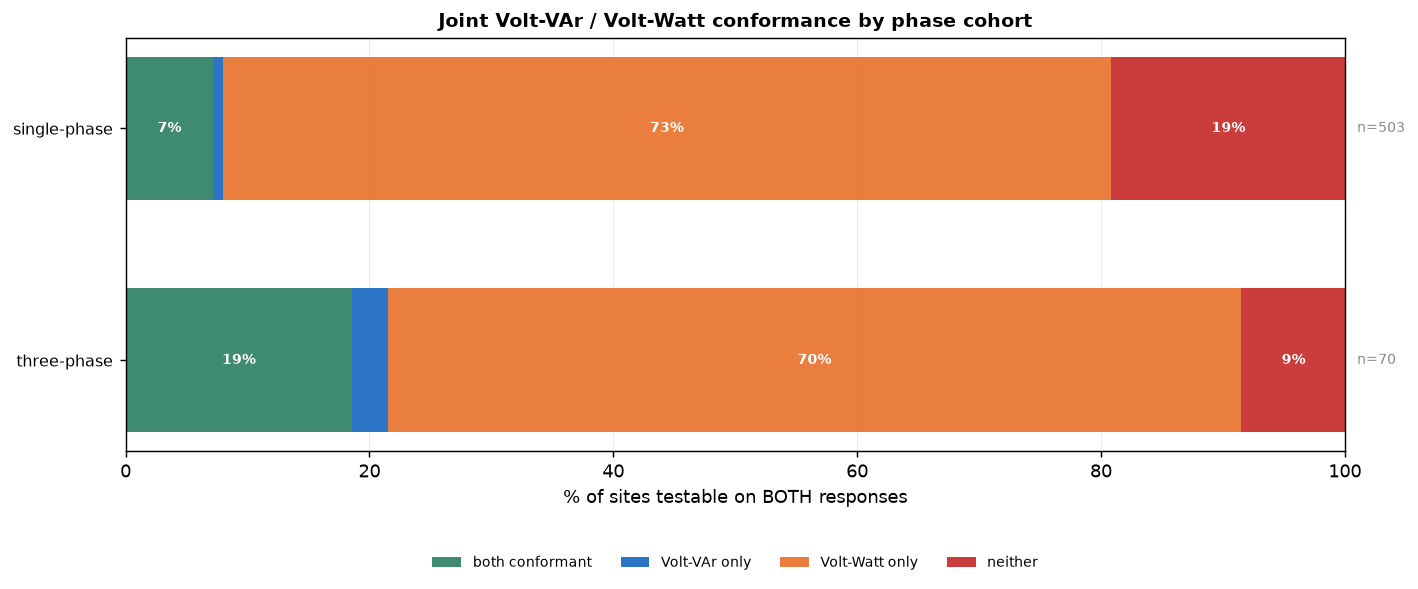


JOINT CONFORMANCE by SYSTEM SIZE (S_99, KVA)


,capacity_band,n_sites,pct_both_conformant,pct_Volt_VAr_only,pct_Volt_Watt_only,pct_neither
0,3-4,6,16.7,0.0,66.7,16.7
1,4-5,155,2.6,0.0,78.7,18.7
2,5-6,164,9.8,0.0,78.7,11.6
3,6-8,132,9.1,3.0,65.9,22.0
4,8-10,90,12.2,2.2,60.0,25.6
5,>10,26,19.2,0.0,73.1,7.7


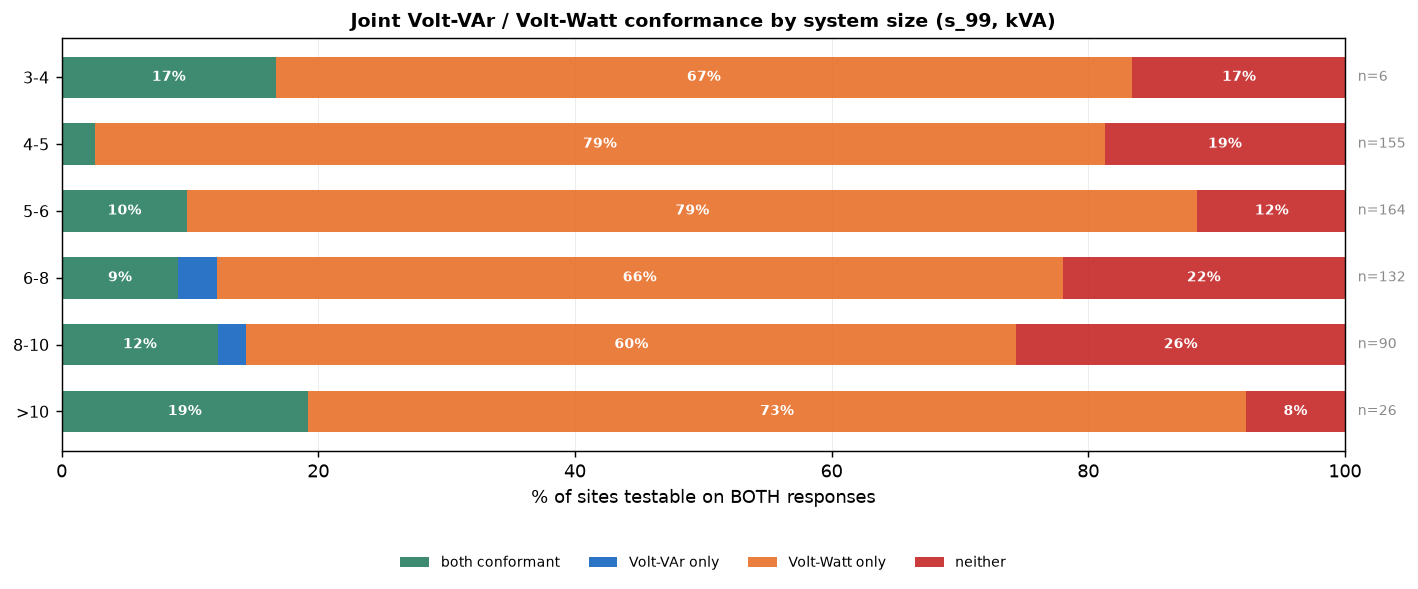


JOINT CONFORMANCE by STATE


,state,n_sites,pct_both_conformant,pct_Volt_VAr_only,pct_Volt_Watt_only,pct_neither
0,New South Wales,268,8.2,0.4,66.8,24.6
1,Queensland,135,16.3,3.7,65.2,14.8
2,South Australia,170,2.9,0.0,87.1,10.0


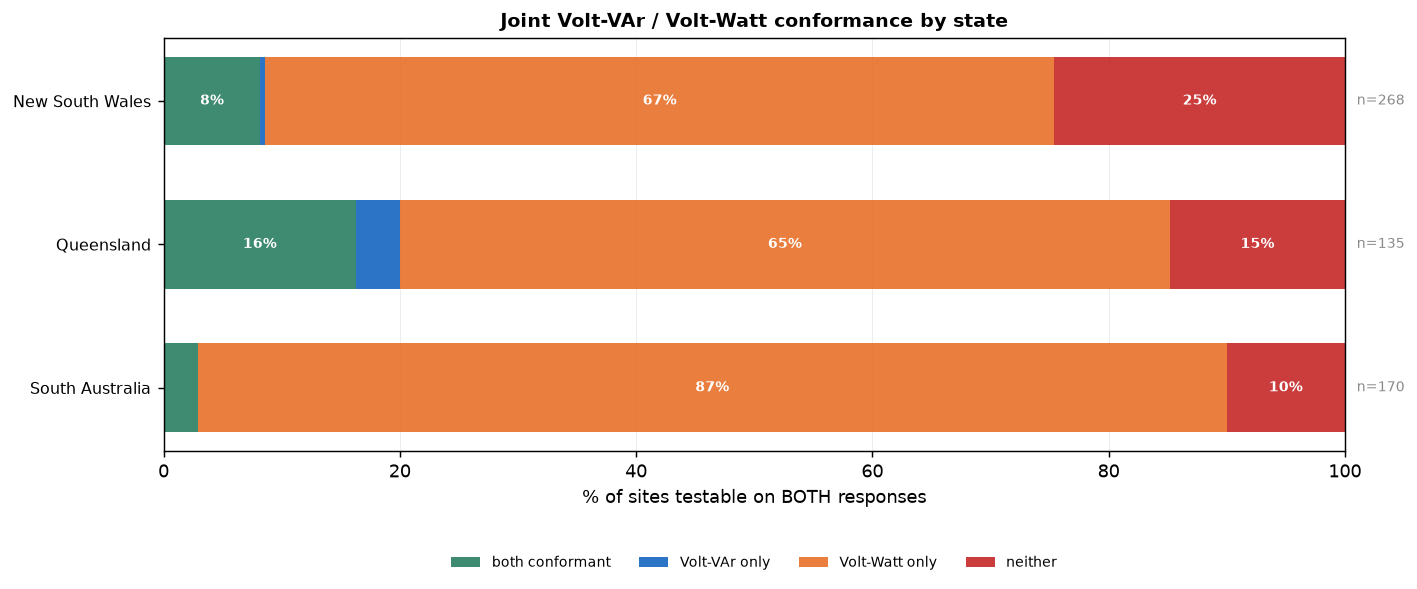

In [30]:
for dimension, label in [("cohort", "phase cohort"),
                         ("capacity_band", "system size (s_99, kVA)"),
                         ("state", "state")]:
    bd = cf.joint_breakdown(joint, dimension)
    print(f"\n{'=' * 90}\nJOINT CONFORMANCE by {label.upper()}\n{'=' * 90}")
    display(bd)
    display(plots.plot_joint_conformance(
        bd, dimension, label=f"Joint Volt-VAr / Volt-Watt conformance by {label}"))

### Are the two failures independent?

This is what the cross-tab is really for. If the two failures co-occur more than chance,
the likely story is **per-inverter** — a commissioning or firmware state that disables both
responses together. If they are independent, they are two separate settings that happen to
be wrong in different populations, and the fixes differ.

Reported as an odds ratio with a **permutation** p-value (shuffling one verdict against the
other), which needs no distributional assumption and copes with the small cell counts this
2×2 usually has. The Haldane correction keeps it finite when a cell is zero — which also
makes it look sturdier than it is, so `smallest_cell` is reported and the reading is
downgraded to *descriptive only* below 10.

In [31]:
independence = cf.joint_independence(joint)
for k, v in independence.items():
    print(f"  {k:18} {v}")

  n_testable         573
  both_fail          103
  vvar_fail_only     415
  vwatt_fail_only    6
  neither_fails      49
  smallest_cell      6
  odds_ratio         1.897
  null_median_or     1.028
  p_value            0.0676
  reading            UNRELIABLE — smallest cell is 6. no evidence against independence, but an odds ratio on this few sites is not evidence; treat as descriptive only.


### The sites that conform to only one

The handoff to notebook 05. `Volt-VAr only` and `Volt-Watt only` are the interesting
populations: something is configured correctly on one response and not the other, in the
same inverter — which is much harder to explain away as a data artefact than a site
failing everything.

In [32]:
one_only = joint[joint.joint_class.isin(["Volt-VAr only", "Volt-Watt only"])].copy()
display(one_only.joint_class.value_counts())

cols = ["site_alias", "joint_class", "cohort", "state", "postcode", "s_99",
        "capacity_band", "vvar_verdict", "vvar_nonconf_frac", "vvar_assessable",
        "vwatt_verdict", "vwatt_nonconf_frac", "vwatt_exposed"]
display(one_only[cols].sort_values(["joint_class", "vvar_nonconf_frac"]).head(20))

joint.to_csv(C.ARTEFACT_DIR / "joint_conformance_by_site.csv", index=False)
print(f"\nAll {len(joint):,} sites -> "
      f"{C.ARTEFACT_DIR / 'joint_conformance_by_site.csv'}")

joint_class
Volt-Watt only    415
Volt-VAr only       6
Name: count, dtype: int64

,site_alias,joint_class,cohort,state,postcode,s_99,capacity_band,vvar_verdict,vvar_nonconf_frac,vvar_assessable,vwatt_verdict,vwatt_nonconf_frac,vwatt_exposed
1012,AUS425,Volt-VAr only,single-phase,Queensland,4037,7.362183,6-8,conformant,0.000066,30478.0,non-conformant,0.191882,271
63,AUS066,Volt-VAr only,single-phase,Queensland,4034,7.668667,6-8,conformant,0.000083,36016.0,non-conformant,0.214233,14895
683,AUS1538,Volt-VAr only,three-phase,Queensland,4500,8.538530,8-10,conformant,0.000153,32700.0,non-conformant,0.500000,2
572,AUS1436,Volt-VAr only,single-phase,Queensland,4073,7.169655,6-8,conformant,0.017936,35069.0,non-conformant,0.633333,30
1256,AUS672,Volt-VAr only,three-phase,New South Wales,2330,8.412072,8-10,conformant,0.027840,27658.0,non-conformant,0.250000,4
96,AUS099,Volt-VAr only,single-phase,Queensland,4208,6.014281,6-8,conformant,0.094672,35417.0,non-conformant,1.000000,1
387,AUS1266,Volt-Watt only,single-phase,Queensland,4505,3.974772,3-4,non-conformant,0.113417,33302.0,conformant,0.000000,1
1084,AUS497,Volt-Watt only,single-phase,South Australia,5084,5.005631,5-6,non-conformant,0.130561,29917.0,conformant,0.000000,1
1491,AUS910,Volt-Watt only,single-phase,Queensland,4115,5.004580,5-6,non-conformant,0.151946,32834.0,conformant,0.000000,14
946,AUS357,Volt-Watt only,single-phase,Queensland,4521,4.168673,4-5,non-conformant,0.170690,30488.0,conformant,0.000000,1



All 1,580 sites -> C:\Users\z3553082\OneDrive - UNSW\Documents\GitHub\CICCADA\solar_edge\artefacts\joint_conformance_by_site.csv
